<a href="https://colab.research.google.com/github/MemphisMeng/First-hand-Football/blob/master/Notebooks/Understat_xG_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import asyncio
import aiohttp
import json
import re
import os
import aiofiles
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# --- CONFIGURATION ---
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import glob

INPUT_DIR = "/content/drive/My Drive/Understat_EPL_24_25"
# Find all .json files in the directory
paths = glob.glob(os.path.join(INPUT_DIR, "*.json"))

In [3]:
matches = []
for path in paths:
  try:
      with open(path, 'r', encoding='utf-8') as f:
          data = json.load(f)
          if 'timelineData' not in data:
            matches.append(data)
  except Exception as e:
      print(f"    [Error] Could not load {os.path.basename(path)}: {e}")

In [4]:
xG_df = pd.DataFrame(
    columns=list(matches[0]['shotsData']['a'][0].keys())
)
appearance_df = pd.DataFrame(
    columns=list(list(matches[0]['rostersData']['a'].values())[0].keys()) + ['match_id']
)


In [5]:
for match_ in matches:
  for shot in match_['shotsData']['h']:
    xG_df.loc[xG_df.shape[0]] = list(shot.values())
  for shot in match_['shotsData']['a']:
    xG_df.loc[xG_df.shape[0]] = list(shot.values())

  for _, player in match_['rostersData']['h'].items():
    appearance_df.loc[appearance_df.shape[0]] = list(player.values()) + [match_['match_id']]
  for _, player in match_['rostersData']['a'].items():
    appearance_df.loc[appearance_df.shape[0]] = list(player.values()) + [match_['match_id']]

# Preprocessing

## data types

In [6]:
xG_df['minute'] = xG_df['minute'].astype(int)
xG_df['X'] = xG_df['X'].astype(float)
xG_df['Y'] = xG_df['Y'].astype(float)
xG_df['xG'] = xG_df['xG'].astype(float)
xG_df['h_goals'] = xG_df['h_goals'].astype(int)
xG_df['a_goals'] = xG_df['a_goals'].astype(int)

In [7]:
appearance_df['xG'] = appearance_df['xG'].astype(float)
appearance_df['time'] = appearance_df['time'].astype(int)
appearance_df['goals'] = appearance_df['goals'].astype(int)
appearance_df['own_goals'] = appearance_df['own_goals'].astype(int)
appearance_df['shots'] = appearance_df['shots'].astype(int)

## Necessary additional columns

In [8]:
# boolean of shot results
xG_df['result_boolean'] = xG_df['result'].apply(lambda x: 1 if x == 'Goal' else 0)

# game time segments
def get_period(minute):
  if minute <= 15:
    return '0-15'
  elif minute <= 30:
    return '15-30'
  elif minute <= 45:
    return '30-45'
  elif minute <= 60:
    return '45-60'
  elif minute <= 75:
    return '60-75'
  else:
    return '75-90+'
xG_df['period'] = xG_df['minute'].apply(get_period)

# game state
xG_df['game_state'] = 'tie'
xG_df['game_state'].loc[(xG_df['h_a'] == 'h') & (xG_df['h_goals'] > xG_df['a_goals'])] = 'leading'
xG_df['game_state'].loc[(xG_df['h_a'] == 'a') & (xG_df['h_goals'] < xG_df['a_goals'])] = 'leading'
xG_df['game_state'].loc[(xG_df['h_a'] == 'h') & (xG_df['h_goals'] < xG_df['a_goals'])] = 'trailing'
xG_df['game_state'].loc[(xG_df['h_a'] == 'a') & (xG_df['h_goals'] > xG_df['a_goals'])] = 'trailing'

# goal difference
## how many goals the kickers' teams had scored vs. the opponent what this shot took place
xG_df['goal_diff'] = '0'
xG_df['goal_diff'].loc[xG_df['h_a'] == 'h'] = (xG_df['h_goals'] - xG_df['a_goals']).astype(str)
xG_df['goal_diff'].loc[xG_df['h_a'] == 'a'] = (xG_df['a_goals'] - xG_df['h_goals']).astype(str)
xG_df['goal_diff'].loc[xG_df['goal_diff'].astype(int) <= -4] = '-4-'
xG_df['goal_diff'].loc[xG_df['goal_diff'] >= '4'] = '4+'

# average xG

## xG per shot
A metric to measure how stable a player maintained his finishing quality

In [9]:
xG_per_shot_df = xG_df.groupby(['player_id', 'player']).agg(
    {'xG': ['mean', 'count']}
)
xG_per_shot_df.rename(columns={'mean': 'xG_per_shot'}, inplace=True)

In [10]:
matches_df = appearance_df.groupby(['player_id', 'player']).agg(
    {'match_id': ['nunique']}
)

In [11]:
goals_df = xG_df.loc[xG_df['result'] == 'Goal'].groupby(['player_id', 'player']).agg(
    {'result': ['count']}
)

In [12]:
xG_per_shot_df = pd.merge(
    xG_per_shot_df,
    matches_df,
    left_index=True,
    right_index=True
)
xG_per_shot_df['shots_per_game'] = xG_per_shot_df[('xG', 'count')] / xG_per_shot_df[('match_id', 'nunique')]

In [13]:
xG_per_shot_df = pd.merge(
    xG_per_shot_df,
    goals_df,
    left_index=True,
    right_index=True,
    how='left'
).fillna(0)

In [14]:
xG_per_shot_df.loc[xG_per_shot_df[('xG', 'count')] >= 50].sort_values(by=('xG', 'xG_per_shot'), ascending=False).head()

xG       match_id shots_per_game  \
                               xG_per_shot count  nunique                  
player_id player                                                           
5786      Yoane Wissa             0.230345    90       35       2.571429   
4456      Chris Wood              0.229980    68       36       1.888889   
5735      Jean-Philippe Mateta    0.229458    69       37       1.864865   
5232      Alexander Isak          0.225828    99       34       2.911765   
5220      Kai Havertz             0.223219    53       23       2.304348   

                               result  
                                count  
player_id player                       
5786      Yoane Wissa            18.0  
4456      Chris Wood             20.0  
5735      Jean-Philippe Mateta   14.0  
5232      Alexander Isak         23.0  
5220      Kai Havertz             9.0

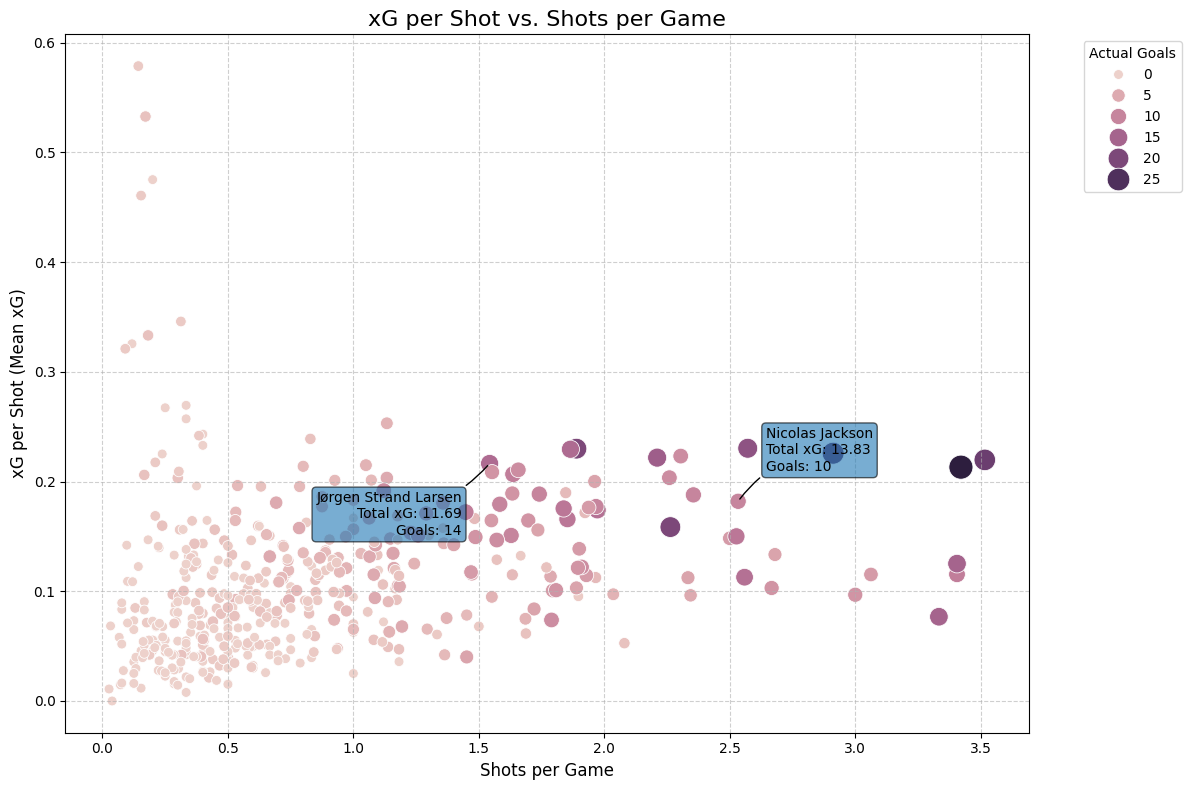

In [15]:
# Prepare the data for plotting
plot_df = xG_per_shot_df.copy().reset_index()
plot_df.columns = [
    'player_id', 'player', 'xG_per_shot', 'shot_count',
    'match_count', 'shots_per_game', 'actual_goals']

# Create the scatter plot
plt.figure(figsize=(12, 8))
sns.scatterplot(data=plot_df, x='shots_per_game', y='xG_per_shot',
                hue='actual_goals',
                size='actual_goals', sizes=(50, 300), legend='brief') # Adjusted size and legend

# Annotate the scatter that belongs to the player Nicolas Jackson.
nicolas_jackson = plot_df[plot_df['player'] == 'Nicolas Jackson'].iloc[0]
strand_larsen = plot_df[plot_df['player'] == 'Jørgen Strand Larsen'].iloc[0]

jackson_annotation = f'''{nicolas_jackson['player']}
Total xG: {(nicolas_jackson['xG_per_shot'] * nicolas_jackson['shot_count']):.2f}
Goals: {int(nicolas_jackson['actual_goals'])}'''

plt.annotate(jackson_annotation,
             (nicolas_jackson['shots_per_game'], nicolas_jackson['xG_per_shot']),
             textcoords="offset points", xytext=(20, 20), ha='left', va='bottom',
             bbox=dict(boxstyle="round,pad=0.3", alpha=0.6),
             arrowprops=dict(arrowstyle="-", connectionstyle="arc3,rad=.2", color='black')) # Adjusted xytext

larsen_annotation = f'''{strand_larsen['player']}
Total xG: {(strand_larsen['xG_per_shot'] * strand_larsen['shot_count']):.2f}
Goals: {int(strand_larsen['actual_goals'])}'''

plt.annotate(larsen_annotation,
             (strand_larsen['shots_per_game'], strand_larsen['xG_per_shot']),
             textcoords="offset points", xytext=(-20, -20), ha='right', va='top',
             bbox=dict(boxstyle="round,pad=0.3", alpha=0.6),
             arrowprops=dict(arrowstyle="-", connectionstyle="arc3,rad=.2", color='black')) # Adjusted xytext and alignment

plt.title('xG per Shot vs. Shots per Game', fontsize=16)
plt.xlabel('Shots per Game', fontsize=12)
plt.ylabel('xG per Shot (Mean xG)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Actual Goals', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [16]:
from scipy import stats
r1, p1 = stats.pearsonr(xG_per_shot_df[('xG', 'xG_per_shot')], xG_per_shot_df[('shots_per_game', '')])

## xG per game

In [17]:
xG_whole_season = xG_df.groupby(['player_id', 'player']).agg(
    {'xG': ['sum']}
)

In [18]:
xG_per_game_df1 = pd.merge(
    xG_whole_season,
    matches_df,
    left_index=True,
    right_index=True
)

In [19]:
xG_per_game_df1['xG_per_game'] = xG_per_game_df1[('xG', 'sum')] / xG_per_game_df1[('match_id', 'nunique')]

In [20]:
xG_per_game_df1.loc[(xG_per_game_df1[('match_id', 'nunique')] >= 20) & (xG_per_game_df1['xG_per_game'] > 0)].\
sort_values(by='xG_per_game', ascending=False).head()

,,xG,match_id,xG_per_game
,,sum,nunique,
player_id,player,,,
8260,Erling Haaland,23.954593,31,0.772729
1250,Mohamed Salah,27.706267,38,0.729112
5232,Alexander Isak,22.356988,34,0.657558
5786,Yoane Wissa,20.731060,35,0.592316
5220,Kai Havertz,11.830621,23,0.514375


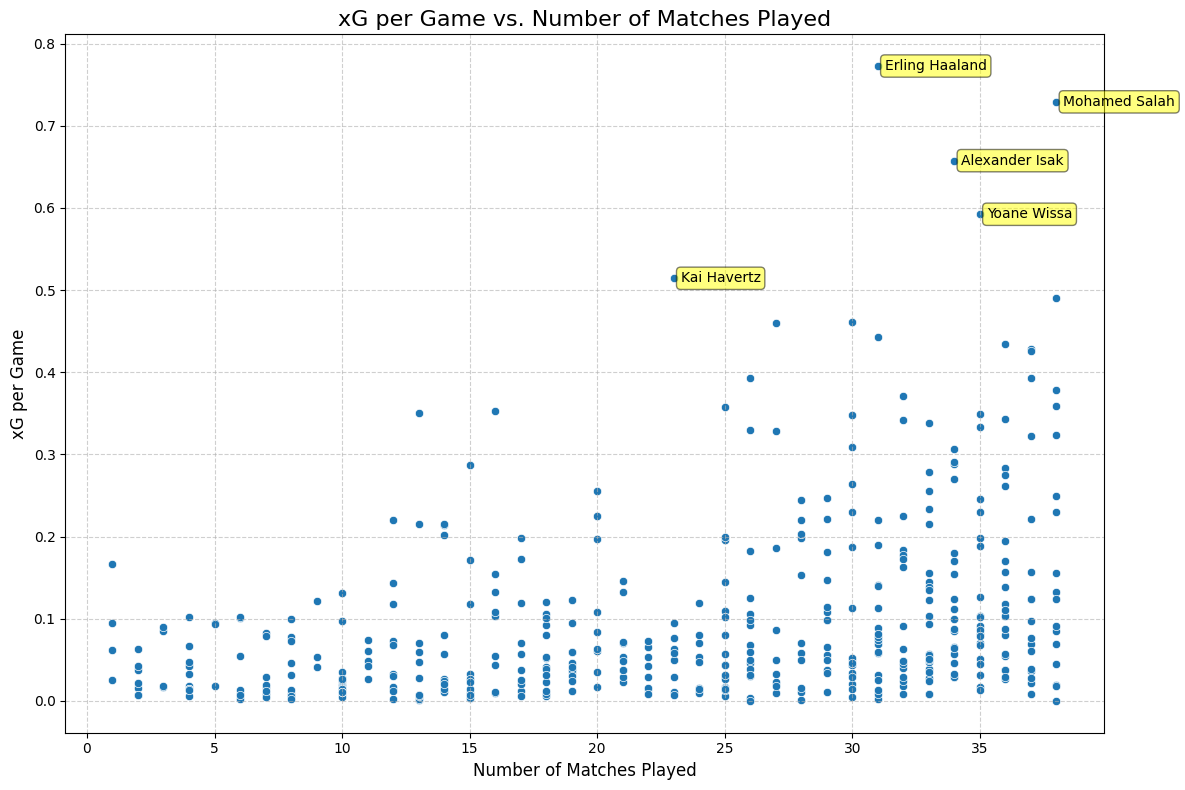

In [21]:
# Prepare the data for plotting
plot_df_game = xG_per_game_df1.copy().reset_index()
plot_df_game.columns = ['player_id', 'player', 'total_xG', 'matches_played', 'xG_per_game']

# Sort to get the top 5 players for annotation
top_5_players_game = plot_df_game.sort_values(by='xG_per_game', ascending=False).head(5)

# Create the scatter plot
plt.figure(figsize=(12, 8))
sns.scatterplot(data=plot_df_game, x='matches_played', y='xG_per_game')

# Annotate the top 5 players
for index, row in top_5_players_game.iterrows():
    plt.annotate(row['player'], (row['matches_played'], row['xG_per_game']),
                 textcoords="offset points", xytext=(5,-5), ha='left', va='bottom',
                 bbox=dict(boxstyle="round,pad=0.3", fc='yellow', alpha=0.5))

plt.title('xG per Game vs. Number of Matches Played', fontsize=16)
plt.xlabel('Number of Matches Played', fontsize=12)
plt.ylabel('xG per Game', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

This is another way to get the same result. Generally speaking, summing up the xGs of all shots in a game can lead to a higher result than the given xG according to some data sources. The following cells serve as a proof that the results are equal to each other.

In [22]:
xG_per_game_df2 = appearance_df.groupby(['player_id', 'player']).agg(
    {'xG': ['mean', 'count']}
)
xG_per_game_df2.rename(columns={'mean': 'xG_per_game'}, inplace=True)

In [23]:
xG_per_game_df2.loc[(xG_per_game_df2[('xG', 'count')] >= 20) & (xG_per_game_df2[('xG', 'xG_per_game')] > 0)].\
sort_values(by=('xG', 'xG_per_game'), ascending=False).head()

xG      
                         xG_per_game count
player_id player                          
8260      Erling Haaland    0.772729    31
1250      Mohamed Salah     0.729112    38
5232      Alexander Isak    0.657558    34
5786      Yoane Wissa       0.592316    35
5220      Kai Havertz       0.514375    23

## xG per 90 minutes
---
Players might not play the whole game though they appeared in one. To better adjust the difference in the time length, I'm going to calculate the xG per 90 minutes.

In [24]:
xG_per_90min_df = appearance_df.groupby(['player_id', 'player']).agg(
    {'xG': ['sum'], 'time': ['sum']}
)
# xG_per_90min_df['xG_per_90min'] = xG_per_90min_df[('xG', 'sum')]
xG_per_90min_df['xG_per_90min'] = xG_per_90min_df[('xG', 'sum')] / (xG_per_90min_df[('time', 'sum')] / 90)

In [25]:
xG_per_90min_df = pd.merge(
    xG_per_90min_df,
    matches_df,
    left_index=True,
    right_index=True
)
xG_per_90min_df['time_played_per_game'] = xG_per_90min_df[('time', 'sum')] / xG_per_90min_df[('match_id', 'nunique')]

In [26]:
xG_per_90min_df.loc[(xG_per_90min_df[('time', 'sum')] >= 1800) & (xG_per_90min_df['xG_per_90min'] > 0)].\
sort_values(by='xG_per_90min', ascending=False).head()

,,xG,time,xG_per_90min,match_id,time_played_per_game
,,sum,sum,,nunique,
player_id,player,,,,,
8260,Erling Haaland,23.954593,2749,0.784254,31,88.677419
1250,Mohamed Salah,27.706267,3392,0.735131,38,89.263158
5232,Alexander Isak,22.356988,2822,0.713015,34,83.000000
5786,Yoane Wissa,20.731060,2943,0.633977,35,84.085714
8865,Ollie Watkins,18.632458,2666,0.629003,38,70.157895


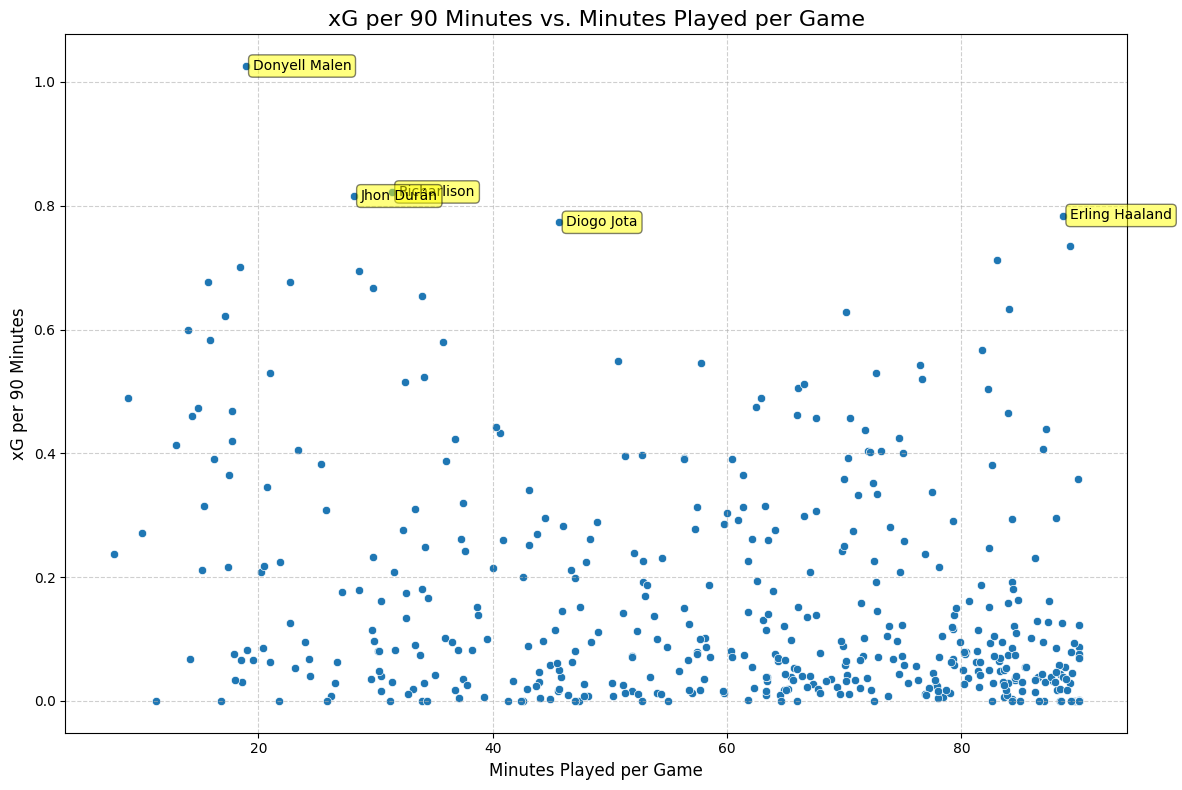

In [27]:
# Prepare the data for plotting
plot_df_90min = xG_per_90min_df.copy().reset_index()
plot_df_90min.columns = ['player_id', 'player', 'total_xG', 'total_time', 'xG_per_90min', 'matches_played', 'time_played_per_game']
plot_df_90min = plot_df_90min.loc[(plot_df_90min['total_time'] >= 90)] # ignore those who didn't play 90 enough minutes
# Sort to get the top 5 players for annotation
top_5_players_90min = plot_df_90min.sort_values(by='xG_per_90min', ascending=False).head(5)

# Create the scatter plot
plt.figure(figsize=(12, 8))
sns.scatterplot(data=plot_df_90min, x='time_played_per_game', y='xG_per_90min', )

# Annotate the top 5 players
for index, row in top_5_players_90min.iterrows():
    plt.annotate(row['player'], (row['time_played_per_game'], row['xG_per_90min']),
                 textcoords="offset points", xytext=(5,-5), ha='left', va='bottom',
                 bbox=dict(boxstyle="round,pad=0.3", fc='yellow', alpha=0.5))

plt.title('xG per 90 Minutes vs. Minutes Played per Game', fontsize=16)
plt.xlabel('Minutes Played per Game', fontsize=12)
plt.ylabel('xG per 90 Minutes', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Difference between goals and xGs
And we can evaluate how well the players capitalised the scoring chances by comparing their actual Gs and xGs.

In [28]:
goal_diff_df = pd.merge(
    xG_whole_season,
    goals_df,
    how='left',
    left_index=True,
    right_index=True
).fillna(0)
goal_diff_df['goal_diff'] = goal_diff_df[('result', 'count')] - goal_diff_df[('xG', 'sum')]
goal_diff_df.sort_values(by='goal_diff', ascending=False)

,,xG,result,goal_diff
,,sum,count,
player_id,player,,,
7080,Matheus Cunha,8.446299,15.0,6.553701
6552,Bryan Mbeumo,13.632161,20.0,6.367839
4456,Chris Wood,15.638655,20.0,4.361345
2254,Mateo Kovacic,1.806073,6.0,4.193927
500,Alex Iwobi,5.021547,9.0,3.978453
...,...,...,...,...
11735,Sávio,5.246914,1.0,-4.246914
5675,Ismaila Sarr,12.308559,8.0,-4.308559


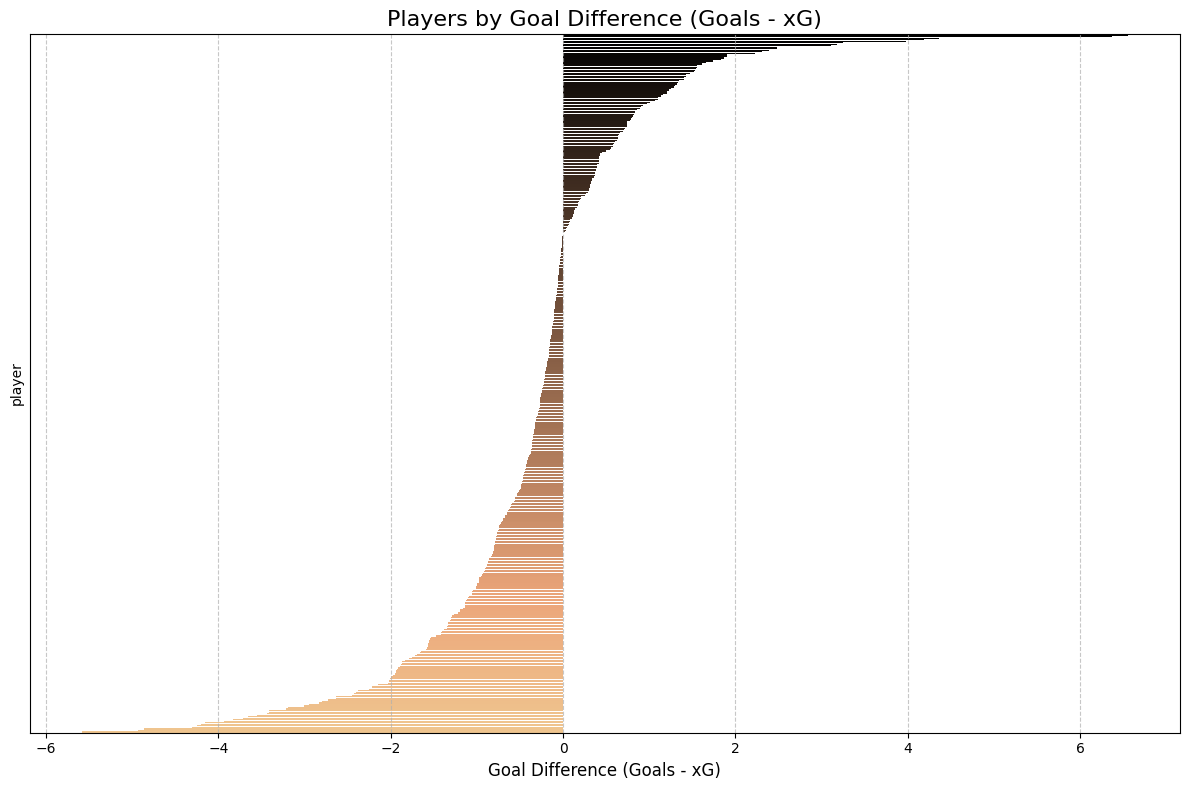

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Flatten the multi-level column names for easier access
goal_diff_df_flat = goal_diff_df.copy()
goal_diff_df_flat.columns = ['_'.join(col).strip() for col in goal_diff_df_flat.columns.values]

# Sort the DataFrame by 'goal_diff' column
sorted_goal_diff_df = goal_diff_df_flat.sort_values(by='goal_diff_', ascending=False)

# Create the horizontal bar plot
plt.figure(figsize=(12, 8))
sns.barplot(x='goal_diff_', y='player', data=sorted_goal_diff_df, palette='copper')

plt.title(f'Players by Goal Difference (Goals - xG)', fontsize=16)
plt.xlabel('Goal Difference (Goals - xG)', fontsize=12)
# plt.ylabel('Total')
plt.yticks([]) # Remove y-axis tick labels
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Team

### xG Score per game per team

In [30]:
team_df = pd.DataFrame(
    columns=['team_id', 'team_name']
)

while team_df.shape[0] < 20:
  for match_ in matches:
    h_roster, a_roster = match_['rostersData'].items()
    h_shots, a_shots = match_['shotsData'].items()

    h_team_id = h_roster[1][list(h_roster[1].keys())[0]]['team_id']
    a_team_id = a_roster[1][list(a_roster[1].keys())[0]]['team_id']

    h_team_name = h_shots[1][0]['h_team']
    a_team_name = a_shots[1][0]['a_team']
    if h_team_id not in team_df['team_id'].values:
      team_df.loc[team_df.shape[0]] = [h_team_id, h_team_name]
    if a_team_id not in team_df['team_id'].values:
      team_df.loc[team_df.shape[0]] = [a_team_id, a_team_name]

In [31]:
xG_scored_per_team_df = appearance_df.groupby('team_id').agg(
    total_xG=('xG', 'sum'),
    total_shots=('shots', 'sum'),
    total_goals=('goals', 'sum')
)

xG_scored_per_team_df['xG_per_game'] = xG_scored_per_team_df['total_xG'] / 38
xG_scored_per_team_df['xG_per_shot'] = xG_scored_per_team_df['total_xG'] / xG_scored_per_team_df['total_shots']
xG_scored_per_team_df['shots_per_game'] = xG_scored_per_team_df['total_shots'] / 38

xG_scored_per_team_df.reset_index()[['team_id', 'xG_per_game']].\
merge(team_df, on='team_id')[['team_name', 'xG_per_game']].\
sort_values(by='xG_per_game', ascending=False)

,team_name,xG_per_game
17,Liverpool,2.495997
15,Arsenal,1.989408
18,Manchester City,1.977246
12,Chelsea,1.957668
8,Bournemouth,1.956609
16,Newcastle United,1.897041
11,Crystal Palace,1.804795
3,Brentford,1.795472
6,Aston Villa,1.763897
14,Tottenham,1.739754


In [32]:
xG_scored_per_team_df.reset_index()[['team_id', 'xG_per_shot']].\
merge(team_df, on='team_id')[['team_name', 'xG_per_shot']].\
sort_values(by='xG_per_shot', ascending=False)

,team_name,xG_per_shot
3,Brentford,0.154712
17,Liverpool,0.146370
6,Aston Villa,0.138488
15,Arsenal,0.138457
16,Newcastle United,0.137835
14,Tottenham,0.133288
11,Crystal Palace,0.133169
8,Bournemouth,0.128413
12,Chelsea,0.125028
0,Brighton,0.123902


In [33]:
xG_scored_per_team_df.reset_index()[['team_id', 'shots_per_game']].\
merge(team_df, on='team_id')[['team_name', 'shots_per_game']].\
sort_values(by='shots_per_game', ascending=False)

,team_name,shots_per_game
17,Liverpool,17.052632
18,Manchester City,16.000000
12,Chelsea,15.657895
8,Bournemouth,15.236842
15,Arsenal,14.368421
0,Brighton,14.026316
19,Manchester United,13.894737
16,Newcastle United,13.763158
1,Fulham,13.710526
11,Crystal Palace,13.552632


### xG Conceded per game per team

In [34]:
match_xG_sums = appearance_df.groupby(['match_id', 'team_id']).agg(
    {'xG': ('sum', 'count')}
).reset_index()

# Rename the 'xG' column for easier access
match_xG_sums.columns = ['match_id', 'team_id', 'xG_conceded', 'shots_conceded']

# Define a function to swap xG values within each match
def swap_xG_within_match(group):
    if len(group) == 2:
        # Get xG values for the two teams
        xG1 = group.iloc[0]['xG_conceded']
        xG2 = group.iloc[1]['xG_conceded']

        shots_conceded = group.iloc[0]['shots_conceded']
        shots_conceded = group.iloc[0]['shots_conceded']

        # Swap the xG values
        group.loc[group.index[0], 'xG_conceded'] = xG2
        group.loc[group.index[1], 'xG_conceded'] = xG1

        group.loc[group.index[0], 'shots_conceded'] = shots_conceded
        group.loc[group.index[1], 'shots_conceded'] = shots_conceded
    return group

# Apply the function to each match_id group
conceded_xG_df = match_xG_sums.groupby('match_id', group_keys=False).apply(swap_xG_within_match)
total_conceded_xG_df = conceded_xG_df.groupby('team_id').agg(
    {'xG_conceded': ('sum'), 'shots_conceded': ('sum')}
)

In [35]:
total_conceded_xG_df.reset_index(inplace=True)
total_conceded_xG_df['xG_conceded_per_game'] = total_conceded_xG_df['xG_conceded'] / 38
total_conceded_xG_df['xG_conceded_per_shot'] = total_conceded_xG_df['xG_conceded'] / total_conceded_xG_df['shots_conceded']
total_conceded_xG_df['shots_conceded_per_game'] = total_conceded_xG_df['shots_conceded'] / 38

total_conceded_xG_df.\
merge(team_df, on='team_id')[['team_name', 'shots_conceded_per_game']].\
sort_values(by='shots_conceded_per_game', ascending=False)

,team_name,shots_conceded_per_game
0,Brighton,15.842105
1,Fulham,15.736842
9,Southampton,15.631579
5,Ipswich,15.552632
2,Wolverhampton Wanderers,15.447368
10,Leicester,15.394737
13,West Ham,15.368421
4,Nottingham Forest,15.342105
6,Aston Villa,15.289474
17,Liverpool,15.263158


In [36]:
total_conceded_xG_df.\
merge(team_df, on='team_id')[['team_name', 'xG_conceded_per_shot']].\
sort_values(by='xG_conceded_per_shot', ascending=False)

,team_name,xG_conceded_per_shot
9,Southampton,0.169197
10,Leicester,0.149595
5,Ipswich,0.144713
14,Tottenham,0.119900
13,West Ham,0.117015
3,Brentford,0.108820
11,Crystal Palace,0.107158
19,Manchester United,0.106780
2,Wolverhampton Wanderers,0.105379
0,Brighton,0.099685


### Visualization

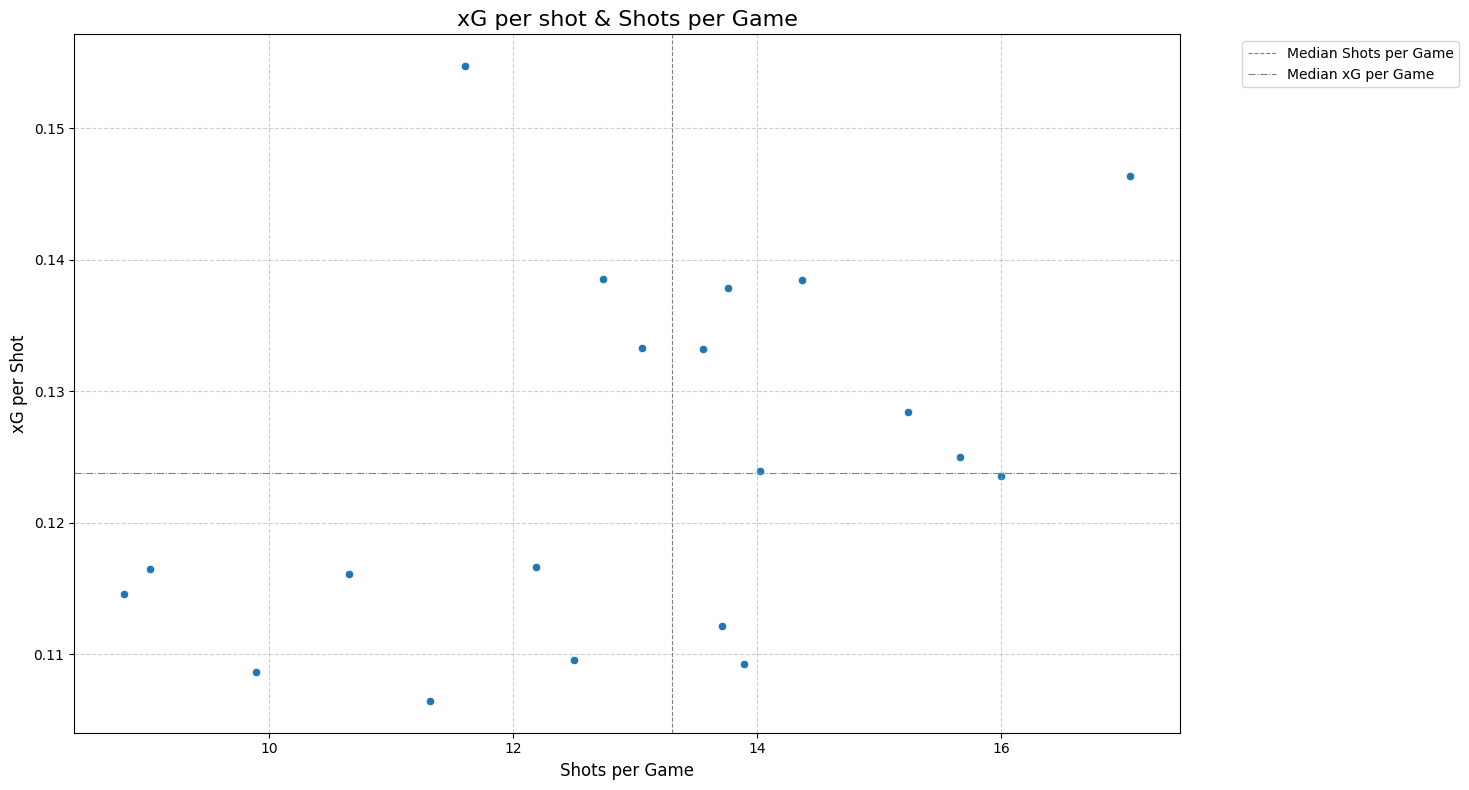

In [37]:
# Prepare the data for plotting
plot_df = xG_scored_per_team_df.reset_index()[['team_id', 'xG_per_shot', 'shots_per_game', 'total_goals']].\
merge(team_df, on='team_id')[['team_name', 'xG_per_shot', 'shots_per_game', 'total_goals']].copy().reset_index()

# Create the scatter plot
plt.figure(figsize=(12, 8))
sns.scatterplot(data=plot_df, x='shots_per_game', y='xG_per_shot',
                # hue='actual_goals',
                # size='total_goals', sizes=(50, 300),
                legend='brief') # Adjusted size and legend

plt.title('xG per shot & Shots per Game', fontsize=16)
plt.xlabel('Shots per Game', fontsize=12)
plt.ylabel('xG per Shot', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.axvline(plot_df['shots_per_game'].median(), color='gray', linestyle='--', linewidth=0.8, label='Median Shots per Game')
plt.axhline(plot_df['xG_per_shot'].median(), color='gray', linestyle='-.', linewidth=0.8, label='Median xG per Game')
plt.tight_layout()
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

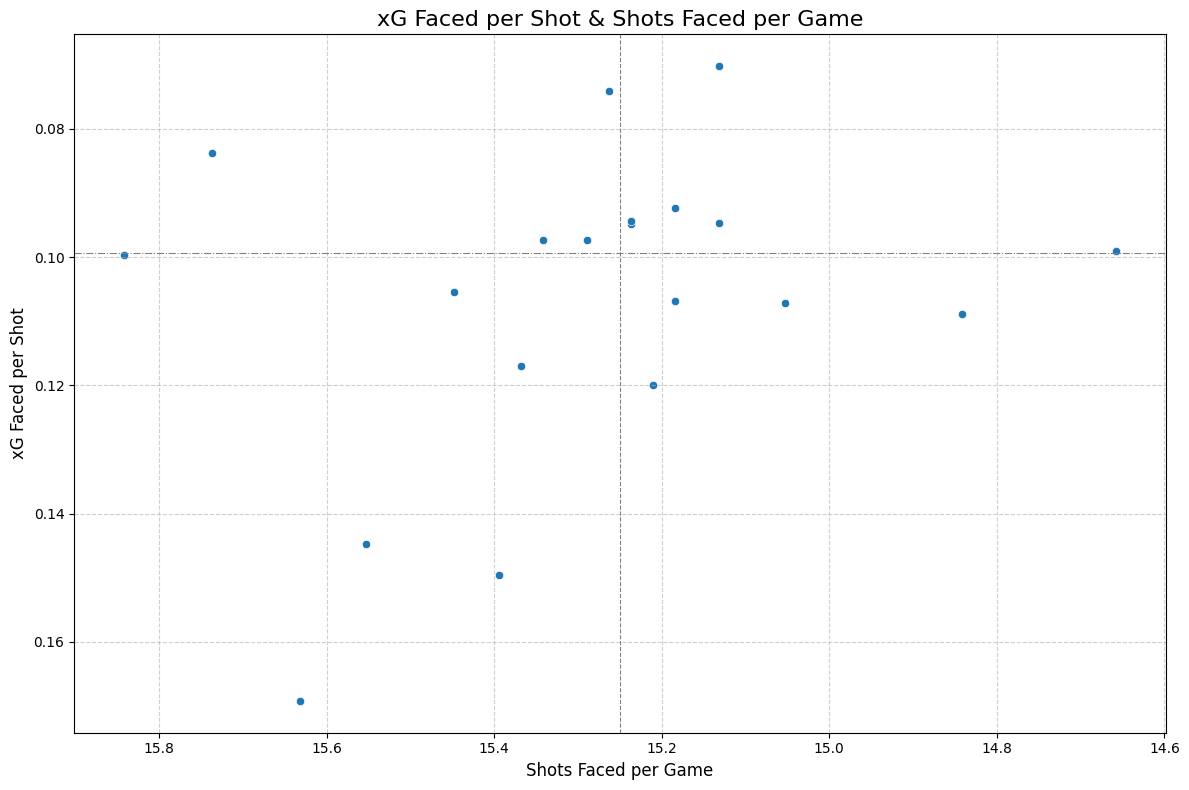

In [38]:
# Prepare the data for plotting
plot_df = total_conceded_xG_df.copy().reset_index()

# Create the scatter plot
plt.figure(figsize=(12, 8))
sns.scatterplot(data=plot_df,
                x='shots_conceded_per_game',
                y='xG_conceded_per_shot',
                # hue='actual_goals',
                # size='total_goals', sizes=(50, 300),
                legend='brief') # Adjusted size and legend

plt.title('xG Faced per Shot & Shots Faced per Game', fontsize=16)
plt.xlabel('Shots Faced per Game', fontsize=12)
plt.ylabel('xG Faced per Shot', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.axvline(plot_df['shots_conceded_per_game'].median(), color='gray', linestyle='--', linewidth=0.8, label='Median Shots Faced per Game')
plt.axhline(plot_df['xG_conceded_per_shot'].median(), color='gray', linestyle='-.', linewidth=0.8, label='Median xG Faced per Game')
plt.gca().invert_yaxis()
plt.gca().invert_xaxis()
plt.tight_layout()
plt.show()

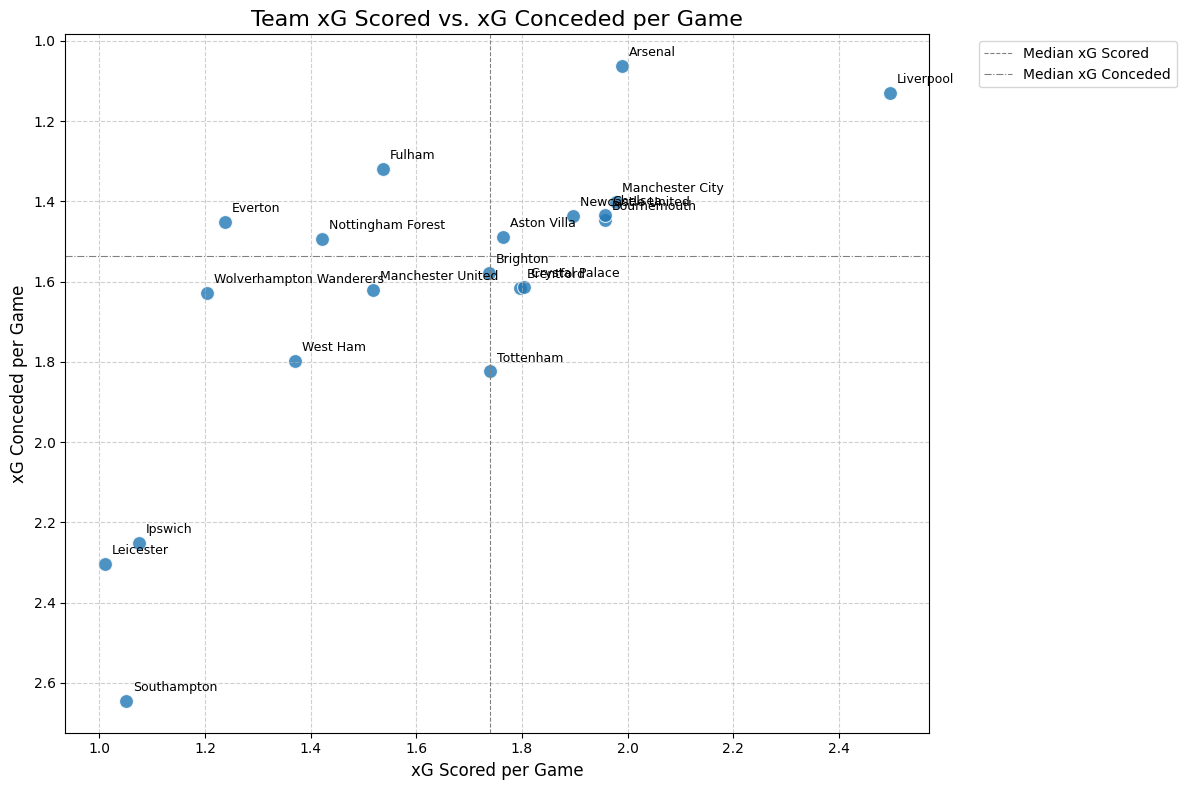

In [39]:
# Merge xG_scored_per_team_df and total_conceded_xG_df
team_xG_analysis_df = pd.merge(
    xG_scored_per_team_df.reset_index(),
    total_conceded_xG_df.reset_index(),
    on='team_id',
    how='inner'
)

# Merge with team_df to get team names
team_xG_analysis_df = pd.merge(
    team_xG_analysis_df,
    team_df,
    on='team_id',
    how='left'
)

# Create the scatter plot
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=team_xG_analysis_df,
    x='xG_per_game',
    y='xG_conceded_per_game',
    s=100,            # Set marker size
    alpha=0.8
)

# Annotate each point with the team name
for i, row in team_xG_analysis_df.iterrows():
    plt.annotate(row['team_name'], (row['xG_per_game'], row['xG_conceded_per_game']),
                 textcoords="offset points", xytext=(5,5), ha='left', va='bottom', fontsize=9)

plt.title('Team xG Scored vs. xG Conceded per Game', fontsize=16)
plt.xlabel('xG Scored per Game', fontsize=12)
plt.ylabel('xG Conceded per Game', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.axvline(team_xG_analysis_df['xG_per_game'].median(), color='gray', linestyle='--', linewidth=0.8, label='Median xG Scored')
plt.axhline(team_xG_analysis_df['xG_conceded_per_game'].median(), color='gray', linestyle='-.', linewidth=0.8, label='Median xG Conceded')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.gca().invert_yaxis() # Invert y-axis to sort ticks descendingly
plt.tight_layout()
plt.show()

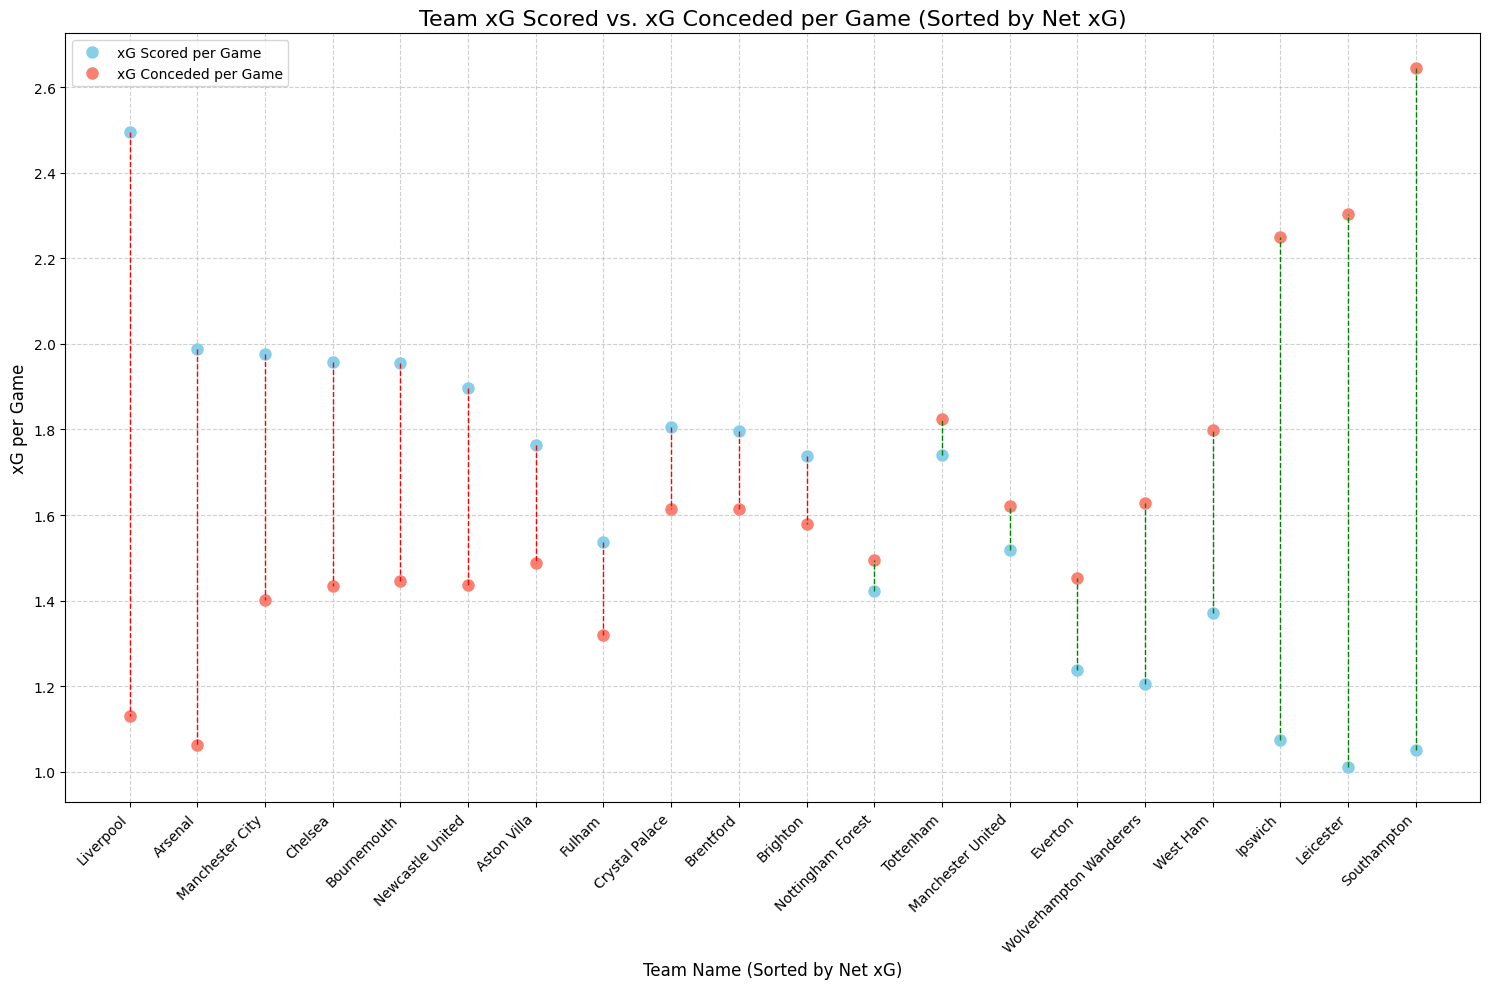

In [40]:
team_xG_analysis_df['net_xG_per_game'] = team_xG_analysis_df['xG_per_game'] - team_xG_analysis_df['xG_conceded_per_game']

# Sort the DataFrame by net_xG_per_game
team_xG_analysis_df_sorted = team_xG_analysis_df.sort_values(by='net_xG_per_game', ascending=False)

# Prepare data for plotting
team_names = team_xG_analysis_df_sorted['team_name']
xG_scored = team_xG_analysis_df_sorted['xG_per_game']
xG_conceded = team_xG_analysis_df_sorted['xG_conceded_per_game']

plt.figure(figsize=(15, 10))

# Plot xG_per_game as dots
plt.plot(team_names, xG_scored, 'o', label='xG Scored per Game', color='skyblue', markersize=8)

# Plot xG_conceded_per_game as dots
plt.plot(team_names, xG_conceded, 'o', label='xG Conceded per Game', color='salmon', markersize=8)

# Connect the dots for the same teams
for i in range(len(team_names)):
  if xG_scored.iloc[i] > xG_conceded.iloc[i]:
    plt.plot([team_names.iloc[i], team_names.iloc[i]], [xG_scored.iloc[i], xG_conceded.iloc[i]],
             color='red', linestyle='--', linewidth=1)
  else:
    plt.plot([team_names.iloc[i], team_names.iloc[i]], [xG_scored.iloc[i], xG_conceded.iloc[i]],
             color='green', linestyle='--', linewidth=1)

plt.title('Team xG Scored vs. xG Conceded per Game (Sorted by Net xG)', fontsize=16)
plt.xlabel('Team Name (Sorted by Net xG)', fontsize=12)
plt.ylabel('xG per Game', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# Some applications of Bayesian Theorem

In [41]:
avg_xG = xG_df['xG'].mean()
sum_xG = xG_df['xG'].sum()

## Probability of goals given different situations

In [42]:
situation_proportions = xG_df['situation'].value_counts(normalize=True)
situation_proportions.rename(index='situtation_proportion', inplace=True)

,situtation_proportion
situation,
OpenPlay,0.740838
FromCorner,0.163900
SetPiece,0.059627
DirectFreekick,0.027232
Penalty,0.008403


In [43]:
goal_proportions = xG_df.loc[xG_df['result'] == 'Goal']['situation'].value_counts(normalize=True)
goal_proportions.rename(index='goal_proportion', inplace=True)

,goal_proportion
situation,
OpenPlay,0.756707
FromCorner,0.114709
Penalty,0.063830
SetPiece,0.052729
DirectFreekick,0.012026


In [44]:
bayesian_df = pd.merge(
    situation_proportions,
    goal_proportions,
    left_index=True,
    right_index=True
)
bayesian_df['goal_probability'] = bayesian_df['goal_proportion'] * avg_xG / bayesian_df['situtation_proportion']
bayesian_df

,situtation_proportion,goal_proportion,goal_probability
situation,,,
OpenPlay,0.740838,0.756707,0.127862
FromCorner,0.163900,0.114709,0.087610
SetPiece,0.059627,0.052729,0.110698
DirectFreekick,0.027232,0.012026,0.055281
Penalty,0.008403,0.063830,0.950938


## Probability of goals given the scorelines
---
We start from comparing the xG between when they are leading, when they tie and when they are behind.

In [45]:
total_shots = xG_df.shape[0]
total_goals = xG_df.loc[xG_df['result'] == 'Goal'].shape[0]

In [46]:
leading_shots_df = \
xG_df.loc[((xG_df['h_a'] == 'h') & (xG_df['h_goals'] > xG_df['a_goals'])) | ((xG_df['h_a'] == 'a') & (xG_df['h_goals'] < xG_df['a_goals']))]

tie_shots_df = \
xG_df.loc[xG_df['h_goals'] == xG_df['a_goals']]

losing_shots_df = \
xG_df.loc[((xG_df['h_a'] == 'h') & (xG_df['h_goals'] < xG_df['a_goals'])) | ((xG_df['h_a'] == 'a') & (xG_df['h_goals'] > xG_df['a_goals']))]

In [47]:
print(f'''
Percentage of shots taken when the team was leading: {leading_shots_df.shape[0] / xG_df.shape[0] * 100}%,
Percentage of shots taken when the team was tied: {tie_shots_df.shape[0] / xG_df.shape[0] * 100}%,
Percentage of shots taken when the team was behind: {losing_shots_df.shape[0] / xG_df.shape[0] * 100}%
''')


Percentage of shots taken when the team was leading: 42.559222514679085%,
Percentage of shots taken when the team was tied: 24.772221097388137%,
Percentage of shots taken when the team was behind: 32.66855638793278%



In [48]:
bayesian_df2 = pd.DataFrame({
    'scoreline_type': ['leading', 'tie', 'losing'],
    'proportion': [
        leading_shots_df.shape[0] / total_shots,
        tie_shots_df.shape[0] / total_shots,
        losing_shots_df.shape[0] / total_shots],
    'goal_distribution': [
        leading_shots_df.loc[leading_shots_df['result'] == 'Goal'].shape[0] / leading_shots_df.shape[0],
        tie_shots_df.loc[tie_shots_df['result'] == 'Goal'].shape[0] / tie_shots_df.shape[0],
        losing_shots_df.loc[losing_shots_df['result'] == 'Goal'].shape[0] / losing_shots_df.shape[0]
    ]
})
bayesian_df2['goal_probability'] = bayesian_df2['goal_distribution'] * avg_xG / bayesian_df2['proportion']
bayesian_df2

,scoreline_type,proportion,goal_distribution,goal_probability
0,leading,0.425592,0.164367,0.048346
1,tie,0.247722,0.088680,0.044812
2,losing,0.326686,0.053610,0.020543


## True xG

### Player level

In [49]:
total_shots_player = xG_df.groupby(['player_id', 'player']).agg(
    {'result': ['count'], 'xG': ['sum']}
)
total_shots_player.rename(columns={'count': 'total_shots', 'sum': 'total_xG'}, inplace=True)
total_goals_player = xG_df.loc[xG_df['result'] == 'Goal'].groupby(['player_id', 'player']).agg(
    {'result': ['count']}
)
total_goals_player.rename(columns={'count': 'total_goals'}, inplace=True)

In [50]:
total_goals_player['goal_proportion'] = total_goals_player[('result', 'total_goals')] / total_goals
total_shots_player['shot_proportion'] = total_shots_player[('result', 'total_shots')] / total_shots

In [51]:
bayesian_df3 = pd.merge(
    left=total_goals_player,
    right=total_shots_player,
    left_index=True,
    right_index=True
)
bayesian_df3['adjusted_xG'] = bayesian_df3['goal_proportion'] * avg_xG / bayesian_df3['shot_proportion']
bayesian_df3[['adjusted_xG']].sort_values(by='adjusted_xG', ascending=False)

,,adjusted_xG
,,
player_id,player,
586,John Stones,1.143881
13387,Romain Esse,1.143881
8089,Kieran Tierney,0.571941
6851,Conor Coady,0.571941
6042,Jan Bednarek,0.457553
...,...,...
8853,Maxence Lacroix,0.038129
7723,John McGinn,0.036899


There are players with adjusted xG > 1, that indicates that some scorers took advantage of their tiny sample size as they made all their only a few shots. So we need to further adjust this using Gamma-Poisson approach.

In [52]:
beta = avg_xG * 100 # equivalent to the sum of xG given that an average player shot 100 times
convertion_rate = total_goals / sum_xG # average player
# alpha = beta * convertion_rate # average player
alpha = beta

In [53]:
bayesian_df3['finishing_coefficient'] = (alpha + bayesian_df3[('result', 'total_goals')]) / (beta + bayesian_df3[('xG', 'total_xG')])

In [54]:
bayesian_df3[['finishing_coefficient']].sort_values(by='finishing_coefficient', ascending=False)

,,finishing_coefficient
,,
player_id,player,
7080,Matheus Cunha,1.312611
2254,Mateo Kovacic,1.292787
6552,Bryan Mbeumo,1.243510
500,Alex Iwobi,1.226827
8127,Amad Diallo Traore,1.188495
...,...,...
900,Adama Traoré,0.798720
6482,Eddie Nketiah,0.788863


In [55]:
xG_df['odd'] = xG_df['xG'] / (1 - xG_df['xG'])

In [56]:
bayesian_df3 = bayesian_df3.loc[:, [('adjusted_xG', ''), ('finishing_coefficient', '')]]

# Flatten the column names of the selected DataFrame
bayesian_df3.columns = ['adjusted_xG', 'finishing_coefficient']

# Perform the merge
xG_df = pd.merge(
    xG_df,
    bayesian_df3,
    left_on=['player_id', 'player'],
    right_index=True,
)

In [57]:
xG_df['adjusted_odd'] = xG_df['odd'] * xG_df['finishing_coefficient']
xG_df['true_xG'] = xG_df['adjusted_odd'] / (1 + xG_df['adjusted_odd'])
true_xG_player = xG_df.groupby(['player_id', 'player']).agg(
    {'true_xG': ['mean', 'sum']}
)

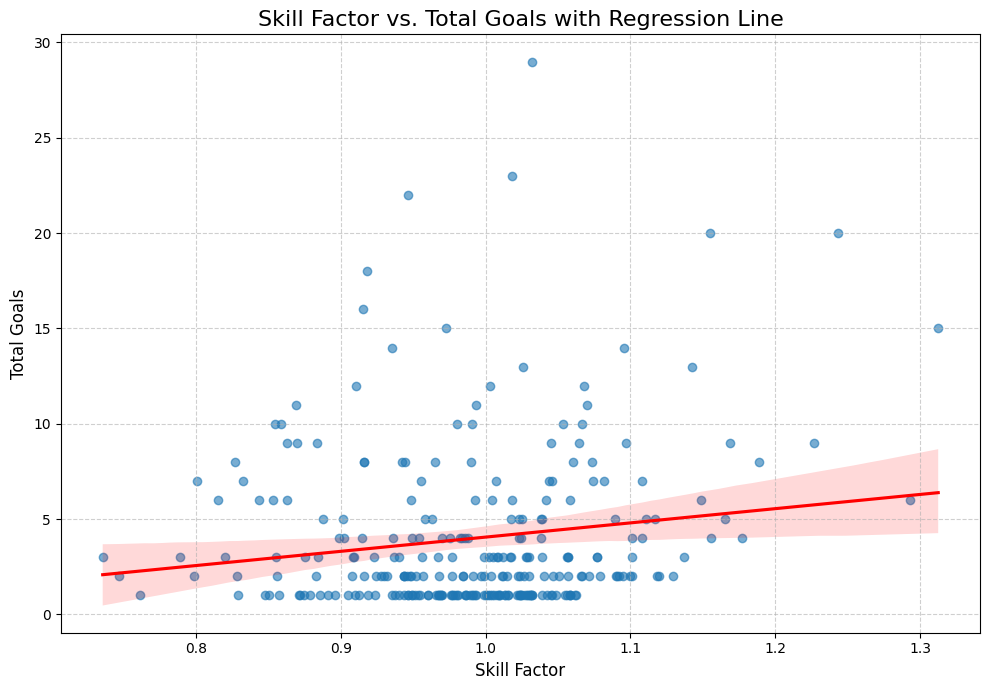

In [58]:
# Reset index of bayesian_df3 to make player_id and player columns
bayesian_df3_reset = bayesian_df3.reset_index()
total_goals_player = total_goals_player.reset_index()
total_goals_player.columns = ['player_id', 'player', 'total_goals', 'goal_proportion'] # Keep goal_proportion

# Merge bayesian_df3_reset with total_goals_player
merged_skill_goals_df = pd.merge(
    bayesian_df3_reset[['player_id', 'player', 'finishing_coefficient']],
    total_goals_player[['player_id', 'player', 'total_goals']],
    on=['player_id', 'player'],
    how='inner'
)

# Create the scatter plot with a linear regression line
plt.figure(figsize=(10, 7))
sns.regplot(data=merged_skill_goals_df, x='finishing_coefficient', y='total_goals', scatter_kws={'alpha':0.6}, line_kws={'color': 'red'})
plt.title('Skill Factor vs. Total Goals with Regression Line', fontsize=16)
plt.xlabel('Skill Factor', fontsize=12)
plt.ylabel('Total Goals', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [59]:
from scipy.stats import linregress, pearsonr

# Perform linear regression to get the correlation coefficient (r)
lin_reg = linregress(merged_skill_goals_df['finishing_coefficient'], merged_skill_goals_df['total_goals'])
r_squared = lin_reg.rvalue**2

print(f"R-squared between finishing_coefficient and Total Goals: {r_squared:.4f}")

R-squared between finishing_coefficient and Total Goals: 0.0238


In [60]:
pearsonr(merged_skill_goals_df['finishing_coefficient'], merged_skill_goals_df['total_goals'])

PearsonRResult(statistic=np.float64(0.15425115186572438), pvalue=np.float64(0.010997024281380819))

In [61]:
true_xG_player = true_xG_player.reset_index()
true_xG_player.columns = ['player_id', 'player', 'mean_true_xG', 'sum_true_xG']

In [62]:
true_xG_player.sort_values(by='mean_true_xG', ascending=False)[['player', 'mean_true_xG']]

,player,mean_true_xG
88,Romain Esse,0.586416
175,William Saliba,0.522757
209,Kieran Tierney,0.462120
135,John Stones,0.349379
253,Daniel Jebbison,0.336376
...,...,...
17,Djed Spence,0.039504
250,Moisés Caicedo,0.035322
76,Yukinari Sugawara,0.033422
72,Jack Taylor,0.031745


In [63]:
merged_xG_goals_df = pd.merge(
    true_xG_player,
    total_goals_player[['player_id', 'player', 'total_goals']],
    on=['player_id', 'player'],
    how='left'
).fillna(0)

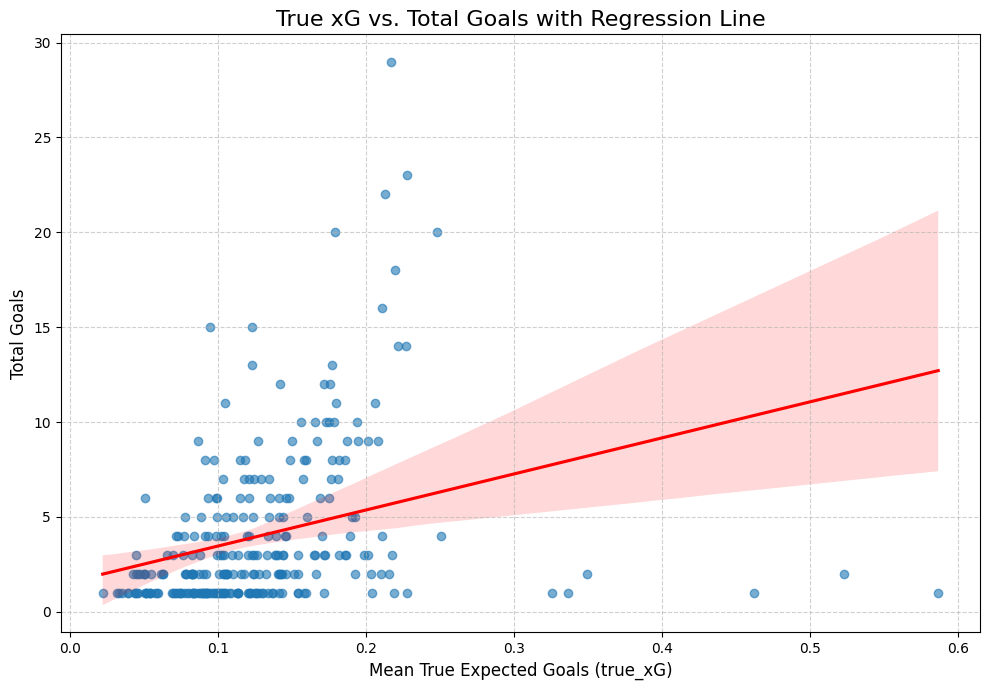

In [64]:
plt.figure(figsize=(10, 7))
sns.regplot(data=merged_xG_goals_df, x='mean_true_xG', y='total_goals', scatter_kws={'alpha':0.6}, line_kws={'color': 'red'})
plt.title('True xG vs. Total Goals with Regression Line', fontsize=16)
plt.xlabel('Mean True Expected Goals (true_xG)', fontsize=12)
plt.ylabel('Total Goals', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [65]:
# Perform linear regression to get the correlation coefficient (r)
lin_reg = linregress(merged_xG_goals_df['mean_true_xG'], merged_xG_goals_df['total_goals'])
r_squared = lin_reg.rvalue**2

print(f"R-squared between Mean True xG and Total Goals: {r_squared:.4f}")

R-squared between Mean True xG and Total Goals: 0.0921


In [66]:
from sklearn.metrics import log_loss

eval_df = xG_df[['xG', 'result', 'true_xG']]
eval_df['result_boolean'] = 0
eval_df['result_boolean'].loc[eval_df['result'] == 'Goal'] = 1

xG_logloss = log_loss(eval_df['result_boolean'], eval_df['xG'])
print(f"Log loss between xG and shot result: {xG_logloss:.4f}")

true_xG_logloss = log_loss(eval_df['result_boolean'], eval_df['true_xG'])
print(f"Log loss between true xG and shot result: {true_xG_logloss:.4f}")

Log loss between xG and shot result: 0.2987
Log loss between true xG and shot result: 0.2946


## Team level
 We can analysze a team's xG performance both defensively and offensively.

### Attack

In [67]:
xG_df['kicker_team'], xG_df['conceded_team'] = None, None
xG_df['kicker_team'].loc[xG_df['h_a'] == 'h'] = xG_df['h_team']
xG_df['kicker_team'].loc[xG_df['h_a'] == 'a'] = xG_df['a_team']

xG_df['conceded_team'].loc[xG_df['h_a'] == 'h'] = xG_df['a_team']
xG_df['conceded_team'].loc[xG_df['h_a'] == 'a'] = xG_df['h_team']

In [68]:
total_shots_team = xG_df.groupby('kicker_team').agg(
    total_shots=('result', 'count'),
    total_xG=('xG', 'sum')
)
total_goals_team = xG_df.loc[xG_df['result'] == 'Goal'].groupby('kicker_team').agg(
    total_goals=('result', 'count'),
)

In [69]:
total_goals_team['goal_proportion'] = total_goals_team['total_goals'] / total_goals
total_shots_team['shot_proportion'] = total_shots_team['total_shots'] / total_shots

In [70]:
bayesian_df4 = pd.merge(
    left=total_goals_team,
    right=total_shots_team,
    left_index=True,
    right_index=True
)
bayesian_df4['adjusted_xG'] = bayesian_df4['goal_proportion'] * avg_xG / bayesian_df4['shot_proportion']
bayesian_df4[['adjusted_xG']].sort_values(by='adjusted_xG', ascending=False)

,adjusted_xG
kicker_team,
Brentford,0.188196
Liverpool,0.164796
Newcastle United,0.164480
Wolverhampton Wanderers,0.163853
Tottenham,0.157155
Nottingham Forest,0.151279
Arsenal,0.149396
Fulham,0.147150
Leicester,0.145185


In [71]:
bayesian_df4['finishing_coefficient'] = (alpha + bayesian_df4['total_goals']) / (beta + bayesian_df4['total_xG'])

In [72]:
convertion_rate

np.float64(0.874216458164751)

In [73]:
bayesian_df4[['finishing_coefficient']].sort_values(by='finishing_coefficient', ascending=False)

,finishing_coefficient
kicker_team,
Wolverhampton Wanderers,1.208475
Nottingham Forest,1.083528
Fulham,1.030614
Brentford,1.010253
Brighton,1.008610
Ipswich,0.997191
Newcastle United,0.995997
Tottenham,0.986315
Manchester City,0.983978


In [74]:
bayesian_df4 = bayesian_df4[['adjusted_xG', 'finishing_coefficient']]

# Perform the merge
xG_df_for = pd.merge(
    xG_df,
    pd.merge(team_df, bayesian_df4, left_on='team_name', right_index=True)[['team_id', 'team_name', 'finishing_coefficient']],
    left_on='kicker_team',
    right_on='team_name',
    suffixes=('_player', '_team')
)

In [75]:
xG_df_for['adjusted_odd_team'] = xG_df_for['odd'] * xG_df_for['finishing_coefficient_team']
xG_df_for['true_xG_team'] = xG_df_for['adjusted_odd_team'] / (1 + xG_df_for['adjusted_odd_team'])
true_xG_team = xG_df_for.groupby('kicker_team').agg(
    {'true_xG_team': ['mean', 'sum']}
)

In [76]:
true_xG_team = xG_df_for.groupby('kicker_team').agg(
    true_xG_for=('true_xG_team', 'mean')
)
true_xG_team.sort_values(by='true_xG_for', ascending=False)

,true_xG_for
kicker_team,
Brentford,0.163537
Liverpool,0.147287
Newcastle United,0.144129
Tottenham,0.138508
Crystal Palace,0.137334
Arsenal,0.136138
Aston Villa,0.134115
Leicester,0.129509
Wolverhampton Wanderers,0.127848


### Defence

In [79]:
true_xG_conceded_team = xG_df_for.groupby('conceded_team').agg(
    {'true_xG_team': 'mean',}
)

In [80]:
total_shots_conceded = xG_df.groupby('conceded_team').agg(
    total_shots=('result', 'count'),
    total_xG=('xG', 'sum')
)
total_goals_conceded = xG_df.loc[xG_df['result'] == 'Goal'].groupby('conceded_team').agg(
    total_goals=('result', 'count'),
)

In [81]:
total_goals_conceded['goal_proportion'] = total_goals_conceded['total_goals'] / total_goals
total_shots_conceded['shot_proportion'] = total_shots_conceded['total_shots'] / total_shots

bayesian_df5 = pd.merge(
    left=total_goals_conceded,
    right=total_shots_conceded,
    left_index=True,
    right_index=True
)
bayesian_df5['adjusted_xG'] = bayesian_df5['goal_proportion'] * avg_xG / bayesian_df5['shot_proportion']

bayesian_df5['defence_coefficient'] = (alpha + bayesian_df5['total_goals']) / (beta + bayesian_df5['total_xG'])

In [82]:
bayesian_df5[['defence_coefficient']].sort_values(by='defence_coefficient')

,defence_coefficient
conceded_team,
Crystal Palace,0.854485
Everton,0.885820
Chelsea,0.888854
Manchester City,0.889579
Nottingham Forest,0.903241
Newcastle United,0.918763
Southampton,0.920738
Manchester United,0.924122
Arsenal,0.940784


In [83]:
xG_df_against = pd.merge(
    xG_df,
    pd.merge(team_df, bayesian_df5, left_on='team_name', right_index=True)[['team_id', 'team_name', 'defence_coefficient']],
    left_on='kicker_team',
    right_on='team_name',
    # suffixes=('_player', '_team')
)

xG_df_against['adjusted_odd_defence'] = xG_df_against['odd'] * xG_df_against['defence_coefficient']
xG_df_against['true_xG_defence'] = xG_df_against['adjusted_odd_defence'] / (1 + xG_df_against['adjusted_odd_defence'])
true_xG_conceded_team = xG_df_against.groupby('conceded_team').agg(
    true_xG_against=('true_xG_defence', 'mean')
)
true_xG_conceded_team.sort_values(by='true_xG_against')

,true_xG_against
conceded_team,
Brentford,0.096320
Nottingham Forest,0.113183
Liverpool,0.113991
Arsenal,0.114436
Bournemouth,0.114991
Newcastle United,0.117119
Fulham,0.117906
Everton,0.118038
West Ham,0.121912


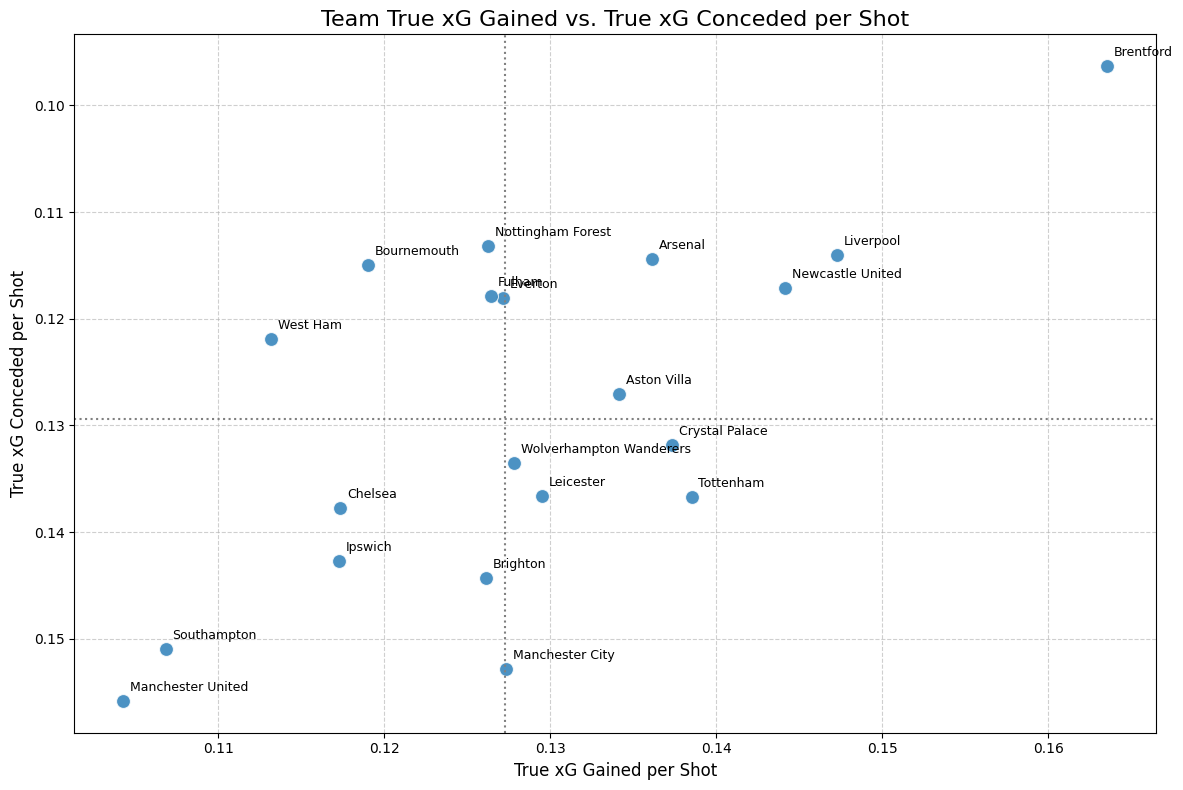

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

# Merge the dataframes
team_true_xG_df = pd.merge(
    left=true_xG_team,
    right=true_xG_conceded_team,
    left_index=True,
    right_index=True
).reset_index()

# Rename columns for clarity
team_true_xG_df.columns = ['team_name', 'true_xG_for', 'true_xG_against']

# Create the scatter plot
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=team_true_xG_df,
    x='true_xG_for',
    y='true_xG_against',
    s=100,
    alpha=0.8
)

# Annotate each point with the team name
for i, row in team_true_xG_df.iterrows():
    plt.annotate(row['team_name'], (row['true_xG_for'], row['true_xG_against']),
                 textcoords="offset points", xytext=(5,5), ha='left', va='bottom', fontsize=9)

# Calculate medians for the lines
median_xG_for = team_true_xG_df['true_xG_for'].median()
median_xG_against = team_true_xG_df['true_xG_against'].median()

# Add horizontal and vertical dotted lines
plt.axvline(median_xG_for, color='gray', linestyle=':', linewidth=1.5, label=f'Median True xG Gained ({median_xG_for:.2f})')
plt.axhline(median_xG_against, color='gray', linestyle=':', linewidth=1.5, label=f'Median True xG Conceded per Shot ({median_xG_against:.2f})')

plt.title('Team True xG Gained vs. True xG Conceded per Shot', fontsize=16)
plt.xlabel('True xG Gained per Shot', fontsize=12)
plt.ylabel('True xG Conceded per Shot', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.gca().invert_yaxis() # Invert y-axis for better interpretation (lower xG conceded is better)
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# xG in different period of game time

In [79]:
xG_df.groupby(['period', 'game_state']).agg(
    {'xG': ['mean']}
)

xG
                       mean
period game_state          
0-15   leading     0.151350
       tie         0.123137
       trailing    0.113020
15-30  leading     0.147595
       tie         0.116942
       trailing    0.126543
30-45  leading     0.148713
       tie         0.131474
       trailing    0.117483
45-60  leading     0.159981
       tie         0.120624
       trailing    0.093596
60-75  leading     0.163054
       tie         0.130888
       trailing    0.099057
75-90+ leading     0.171548
       tie         0.116415
       trailing    0.102989

In [80]:
xG_df.groupby(['period', 'goal_diff']).agg(
    {'xG': ['mean']}
)

xG
                      mean
period goal_diff          
0-15   -1         0.126824
       -2         0.091400
       -3         0.110203
       -4-        0.127999
       0          0.123137
       1          0.150657
       2          0.140934
       3          0.153332
       4+         0.182501
15-30  -1         0.123808
       -2         0.118703
       -3         0.133694
       -4-        0.161278
       0          0.116942
       1          0.129364
       2          0.170216
       3          0.139772
       4+         0.166827
30-45  -1         0.134773
       -2         0.093908
       -3         0.119306
       -4-        0.106706
       0          0.131474
       1          0.135712
       2          0.127533
       3          0.194851
       4+         0.210779
45-60  -1         0.095030
       -2         0.092244
       -3         0.069629
       -4-        0.126866
       0          0.120624
       1          0.134029
       2          0.159890
       3          0.196239
       4+         0.217273
60-75  -1         0.102603
       -2         0.096111
       -3         0.108324
       -4-        0.053155
       0          0.130888
       1          0.147623
       2          0.167719
       3          0.179112
       4+         0.202307
75-90+ -1         0.108810
       -2         0.098282
       -3         0.102284
       -4-        0.067548
       0          0.116415
       1          0.154652
       2          0.195400
       3          0.155887
       4+         0.200584

In [81]:
xG_df.groupby('goal_diff').agg(
    {'match_id': ['count']}
)

,match_id
,count
goal_diff,
-1,1420
-2,794
-3,326
-4-,177
0,2101
1,1639
2,1155
3,612


# Game Insights

In [82]:
match_df = appearance_df.groupby(['match_id', 'team_id', 'h_a']).agg(
    {'xG': 'sum', 'goals': 'sum', 'own_goals': 'sum', 'shots': 'sum'}
).reset_index()
home_teams = match_df.loc[match_df['h_a'] == 'h']
home_teams = home_teams[['match_id', 'team_id', 'xG', 'goals', 'own_goals', 'shots']].rename(columns={'team_id': 'home_team_id'})
away_teams = match_df.loc[match_df['h_a'] == 'a']
away_teams = away_teams[['match_id', 'team_id', 'xG', 'goals', 'own_goals', 'shots']].rename(columns={'team_id': 'away_team_id'})
match_df = pd.merge(
    home_teams,
    away_teams,
    on='match_id',
    suffixes=('_home', '_away')
)
match_df['scores_home'] = match_df['goals_home'] + match_df['own_goals_away']
match_df['scores_away'] = match_df['goals_away'] + match_df['own_goals_home']

In [83]:
from collections import defaultdict

team_points = defaultdict(int)
for _, row in match_df.iterrows():
    if row['scores_home'] > row['scores_away']:
        team_points[row['home_team_id']] += 3
    elif row['scores_home'] == row['scores_away']:
        team_points[row['home_team_id']] += 1
        team_points[row['away_team_id']] += 1
    else:
        team_points[row['away_team_id']] += 3

In [84]:
points_df = pd.merge(
    team_df,
    pd.DataFrame(list(team_points.items()), columns=['team_id', 'points']),
    left_on='team_id',
    right_on='team_id'
)

Evaluate the linearity between both coefficients and the total points

In [85]:
import statsmodels.formula.api as smf

# Merge bayesian_df4 (finishing_coefficient) and bayesian_df5 (defence_coefficient)
# Both are indexed by team_name, so a direct merge on index works.
coeff_df = pd.merge(
    left=bayesian_df4,
    right=bayesian_df5,
    left_index=True,
    right_index=True
)

# Merge with points_df. points_df has 'team_name' as a column.
# Reset index of coeff_df so we can merge on 'team_name'.
coeff_df_reset = coeff_df.reset_index()
coeff_df_reset.rename(columns={'kicker_team': 'team_name'}, inplace=True) # Rename the index column

# Final merge with points_df
regression_data = pd.merge(
    left=coeff_df_reset,
    right=points_df[['team_name', 'points']],
    on='team_name',
    how='inner' # Ensure only teams present in all are included
)[['team_name', 'finishing_coefficient', 'defence_coefficient', 'points']]

# Perform multi-variable linear regression using statsmodels
# Define the formula: points ~ finishing_coefficient + defence_coefficient
formula = "points ~ finishing_coefficient + defence_coefficient"

# Create and fit the OLS model
model = smf.ols(formula=formula, data=regression_data)
results = model.fit()

# Print the summary
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                 points   R-squared:                       0.147
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     1.461
Date:                Sat, 24 Jan 2026   Prob (F-statistic):              0.260
Time:                        07:07:39   Log-Likelihood:                -84.717
No. Observations:                  20   AIC:                             175.4
Df Residuals:                      17   BIC:                             178.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                95.81

# Nicolas Jackson vs Jørgen Strand Larsen

## Last Action

In [86]:
xG_df.loc[xG_df['player'] == 'Nicolas Jackson'].groupby('lastAction').agg(
    {'xG': ['mean', 'count']}
)

xG      
                  mean count
lastAction                  
Aerial        0.047919     9
BallRecovery  0.235407     2
BallTouch     0.236357     3
Chipped       0.110703     6
Cross         0.383769     4
HeadPass      0.545521     1
Interception  0.033253     1
None          0.097769     8
Pass          0.176041    29
Rebound       0.287112     4
TakeOn        0.302509     3
Throughball   0.250253     6

In [87]:
xG_df.loc[xG_df['player'] == 'Jørgen Strand Larsen'].groupby('lastAction').agg(
    {'xG': ['mean', 'count']}
)

xG      
                 mean count
lastAction                 
Aerial       0.058988     7
Challenge    0.026569     1
Chipped      0.093793     2
Cross        0.190608    16
HeadPass     0.305096     2
None         0.210126     3
Pass         0.271870    20
Rebound      0.902641     1
Throughball  0.216139     2

## Shot Type

In [88]:
xG_df.loc[xG_df['player'] == 'Nicolas Jackson'].groupby('shotType').agg(
    {'xG': ['mean', 'count']}
)

xG      
               mean count
shotType                 
Head       0.138781    13
LeftFoot   0.166891    16
RightFoot  0.199142    47

In [89]:
xG_df.loc[xG_df['player'] == 'Jørgen Strand Larsen'].groupby('shotType').agg(
    {'xG': ['mean', 'count']}
)

xG      
                   mean count
shotType                     
Head           0.144895    17
LeftFoot       0.237669     8
OtherBodyPart  0.049182     1
RightFoot      0.259855    28

# Advanced visualizations
A session to improve some visualizations in the previous chapters.

## xG Added/Faced per Game & A team's Points

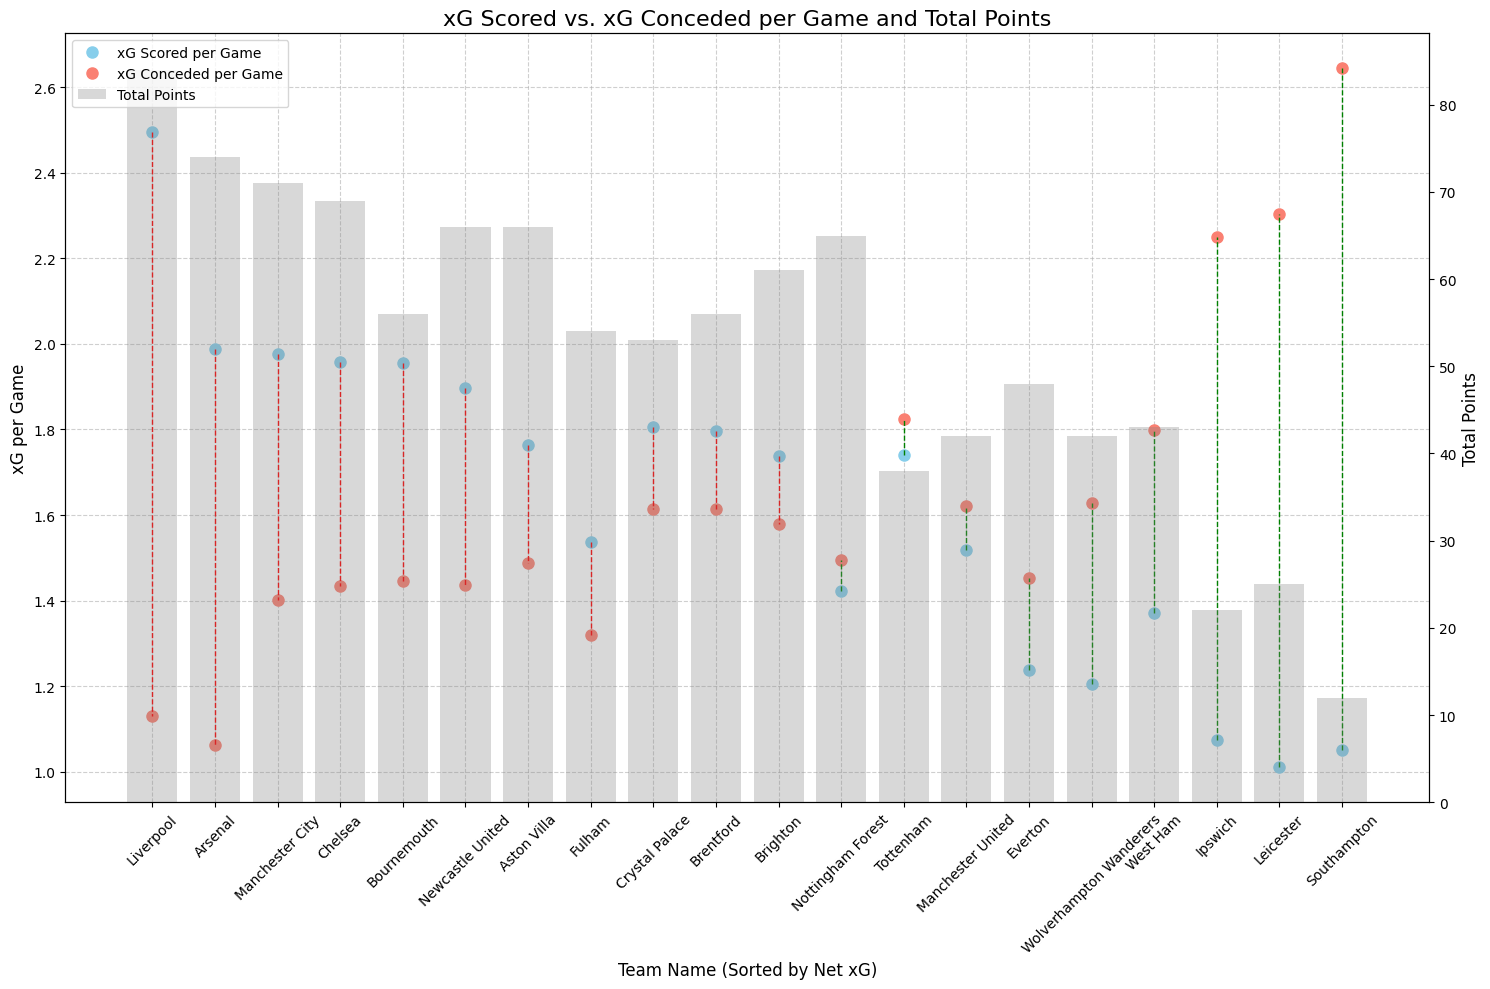

In [90]:
team_xG_analysis_df['net_xG_per_game'] = team_xG_analysis_df['xG_per_game'] - team_xG_analysis_df['xG_conceded_per_game']

# Sort the DataFrame by net_xG_per_game
team_xG_analysis_df_sorted = team_xG_analysis_df.sort_values(by='net_xG_per_game', ascending=False)

# Prepare data for plotting
team_names = team_xG_analysis_df_sorted['team_name']
xG_scored = team_xG_analysis_df_sorted['xG_per_game']
xG_conceded = team_xG_analysis_df_sorted['xG_conceded_per_game']

# Create the main plot (xG Scored vs. xG Conceded)
fig, ax1 = plt.subplots(figsize=(15, 10))

# Plot xG_per_game as dots
ax1.plot(team_names, xG_scored, 'o', label='xG Scored per Game', color='skyblue', markersize=8)

# Plot xG_conceded_per_game as dots
ax1.plot(team_names, xG_conceded, 'o', label='xG Conceded per Game', color='salmon', markersize=8)

# Connect the dots for the same teams
for i in range(len(team_names)):
  if xG_scored.iloc[i] > xG_conceded.iloc[i]:
    ax1.plot([team_names.iloc[i], team_names.iloc[i]], [xG_scored.iloc[i], xG_conceded.iloc[i]],
             color='red', linestyle='--', linewidth=1)
  else:
    ax1.plot([team_names.iloc[i], team_names.iloc[i]], [xG_scored.iloc[i], xG_conceded.iloc[i]],
             color='green', linestyle='--', linewidth=1)

ax1.set_xlabel('Team Name (Sorted by Net xG)', fontsize=12)
ax1.set_ylabel('xG per Game', fontsize=12)
ax1.tick_params(axis='x', rotation=45) # Removed ha='right' as it caused an error
ax1.grid(True, linestyle='--', alpha=0.6)

# Create a second y-axis for team points
ax2 = ax1.twinx()

# Merge points_df with team_xG_analysis_df_sorted to ensure correct order
team_points_df_sorted = pd.merge(team_xG_analysis_df_sorted[['team_id', 'team_name']], points_df, on='team_id', how='left')

# Plot team points as a bar chart on ax2
ax2.bar(team_points_df_sorted['team_name_x'], team_points_df_sorted['points'], alpha=0.3, color='grey', label='Total Points')
ax2.set_ylabel('Total Points', fontsize=12)

# Combine legends
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.title('xG Scored vs. xG Conceded per Game and Total Points', fontsize=16)
plt.tight_layout()
plt.show()

In [92]:
import os
import matplotlib.image as mpimg
from matplotlib.offsetbox import AnnotationBbox, OffsetImage

# Get a list of all files and directories in the /content directory
content_files = os.listdir('/content/drive/MyDrive/england')

# Filter for .png files
png_files = [f for f in content_files if f.endswith('.png')]

In [87]:
import re
import os

# Initialize an empty dictionary for team to image mapping
team_image_mapping = {}
image_directory = '/content/drive/MyDrive/england/'

# Refined function to normalize names for matching
def normalize_for_matching(name):
    # Convert to lowercase and replace spaces/underscores with hyphens
    normalized = name.lower().replace(' ', '-').replace('_', '-')

    # Remove common suffixes/words using regex for whole word matching
    # This list is more comprehensive and includes words found in both team names and image filenames
    suffixes_to_remove_patterns = [
        r'\b(fc|afc|united|town|wanderers|albion|rovers|palace|spurs|north-end|stanley|dons|hotspur|forest|logo|badge|club|hove|and)\b',
    ]

    for pattern in suffixes_to_remove_patterns:
        normalized = re.sub(pattern, '', normalized)

    # Handle specific cases that might still have extra hyphens or need unique mapping adjustments
    normalized = normalized.replace('crystal-palace', 'crystal-palace')
    normalized = normalized.replace('brighton', 'brighton') # fc-brighton-and-hove-albion
    normalized = normalized.replace('tottenham', 'tottenham') # tottenham-hotspur
    normalized = normalized.replace('west-ham', 'west-ham') # west-ham-united
    normalized = normalized.replace('newcastle', 'newcastle') # newcastle-united
    normalized = normalized.replace('manchester-city', 'manchester-city')
    normalized = normalized.replace('manchester-united', 'manchester-united')
    normalized = normalized.replace('aston-villa', 'aston-villa')
    normalized = normalized.replace('leicester', 'leicester')
    normalized = normalized.replace('ipswich', 'ipswich')
    normalized = normalized.replace('southampton', 'southampton')
    normalized = normalized.replace('bournemouth', 'bournemouth') # afc-bournemouth
    normalized = normalized.replace('fulham', 'fulham')
    normalized = normalized.replace('brentford', 'brentford')
    normalized = normalized.replace('everton', 'everton')
    normalized = normalized.replace('liverpool', 'liverpool')
    normalized = normalized.replace('chelsea', 'chelsea')
    normalized = normalized.replace('arsenal', 'arsenal')
    normalized = normalized.replace('nottingham-forest', 'nottingham-forest')
    normalized = normalized.replace('wolverhampton', 'wolverhampton') # wolverhampton-wanderers

    # Clean up multiple hyphens and strip leading/trailing hyphens
    normalized = re.sub(r'-+', '-', normalized).strip('-')
    return normalized

# Prepare normalized team names from `team_df`
normalized_team_names = {team_name: normalize_for_matching(team_name) for team_name in team_df['team_name'].unique()}

# Prepare normalized image filenames with their original paths
normalized_image_filenames_with_paths = {}
for png_file in png_files:
    base_name = os.path.splitext(png_file)[0] # Remove .png extension
    normalized_img_name = normalize_for_matching(base_name)
    if normalized_img_name:
        normalized_image_filenames_with_paths[normalized_img_name] = image_directory + png_file

# Create the mapping based on normalized names
for original_team_name, normalized_team in normalized_team_names.items():
    found_match = False
    # Try to find an exact match first
    if normalized_team in normalized_image_filenames_with_paths:
        team_image_mapping[original_team_name] = normalized_image_filenames_with_paths[normalized_team]
        found_match = True
    else:
        # If no exact match, try to find the best substring match
        for img_norm_name, img_path in normalized_image_filenames_with_paths.items():
            if normalized_team in img_norm_name or img_norm_name in normalized_team:
                team_image_mapping[original_team_name] = img_path
                found_match = True
                break
    if not found_match:
        print(f"Warning: No image found for team: {original_team_name} (normalized: {normalized_team})")

print(f"Team to Image Mapping (updated): {len(team_image_mapping.items())}")
# for team, path in team_image_mapping.items():
    # print(f"{team}: {path}")


Team to Image Mapping (updated): 20


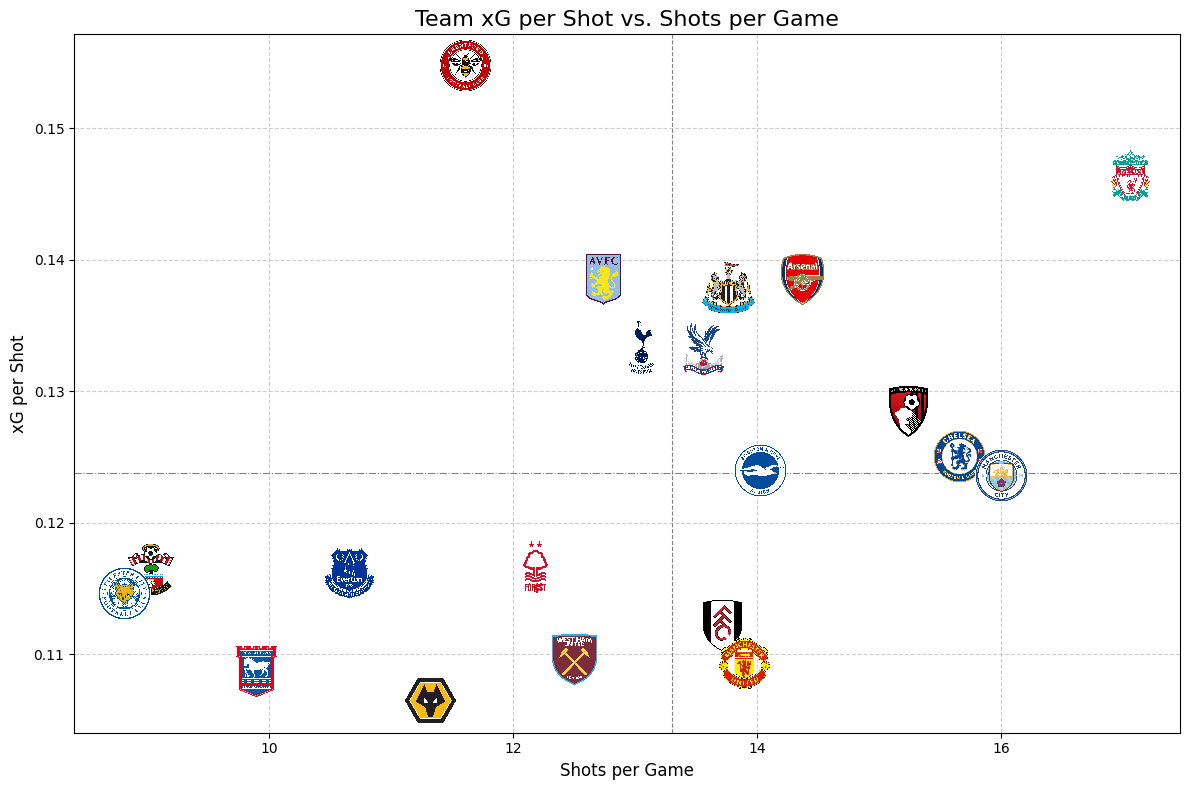

In [118]:
# Prepare the data for plotting (re-creating from original cell logic)
plot_df = xG_scored_per_team_df.reset_index()[['team_id', 'xG_per_shot', 'shots_per_game',]].\
merge(team_df, on='team_id')[['team_name', 'xG_per_shot', 'shots_per_game', ]].copy().reset_index()

# Create the scatter plot foundation
fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(data=plot_df, x='shots_per_game', y='xG_per_shot',
                alpha=0,
                ax=ax) # Set alpha to 0 to make the scatter points invisible, as images will replace them

# Iterate through each team and add their badge as a marker
for index, row in plot_df.iterrows():
    team_name = row['team_name']
    img_path = team_image_mapping.get(team_name)

    if img_path and os.path.exists(img_path):
        try:
            img = mpimg.imread(img_path)
            # Resize the image for better visualization
            imagebox = OffsetImage(img, zoom=0.015) # Adjusted zoom factor
            ab = AnnotationBbox(imagebox, (row['shots_per_game'], row['xG_per_shot']),
                                xycoords='data', frameon=False, pad=0.1)
            ax.add_artist(ab)
        except Exception as e:
            print(f"Could not load image for {team_name} from {img_path}: {e}")
    else:
        print(f"Warning: Image not found for team: {team_name} at path {img_path}")

# Adjust plot title, labels, and grid
plt.title('Team xG per Shot vs. Shots per Game', fontsize=16)
plt.xlabel('Shots per Game', fontsize=12)
plt.ylabel('xG per Shot', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.axvline(plot_df['shots_per_game'].median(), color='gray', linestyle='--', linewidth=0.8, label='Median Shots per Game')
plt.axhline(plot_df['xG_per_shot'].median(), color='gray', linestyle='-.', linewidth=0.8, label='Median xG per Shot')
plt.tight_layout()
plt.show()

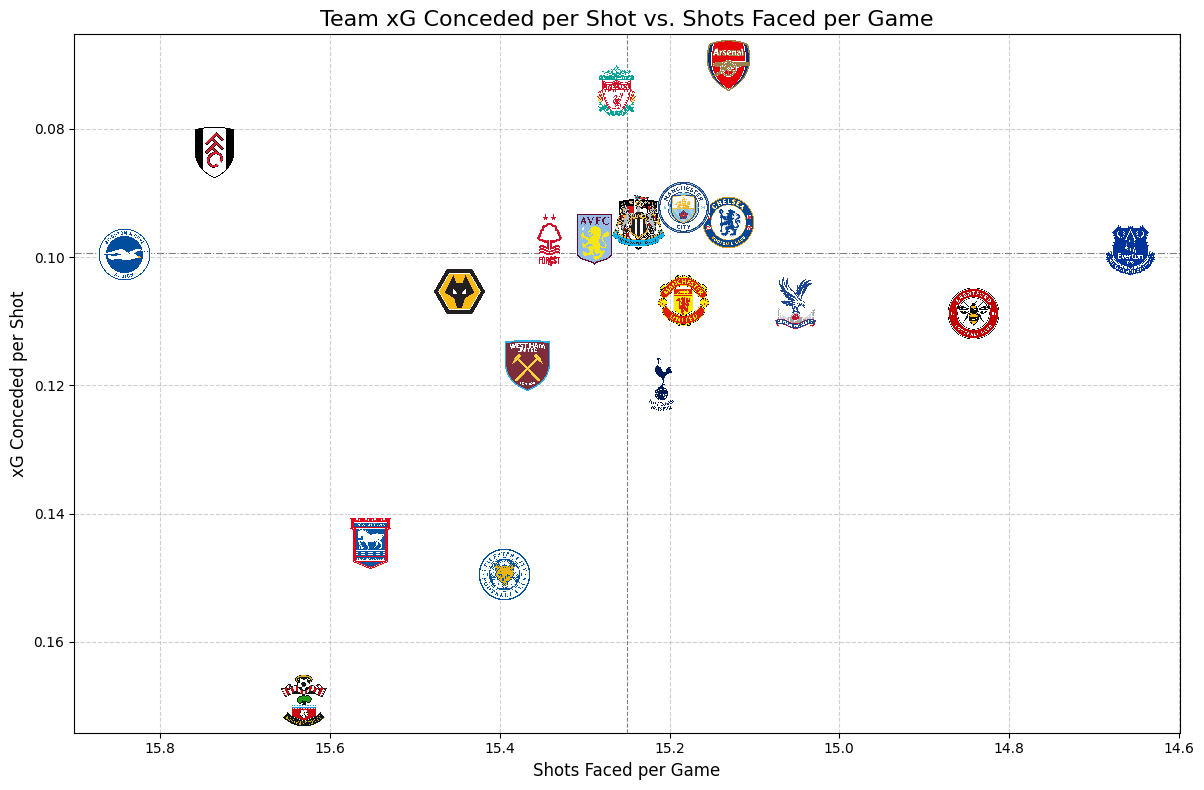

In [95]:
# Prepare the data for plotting (re-creating from original cell logic)
plot_df = total_conceded_xG_df.reset_index()[['team_id', 'xG_conceded_per_shot', 'shots_conceded_per_game', ]].\
merge(team_df, on='team_id')[['team_name', 'xG_conceded_per_shot', 'shots_conceded_per_game', ]].copy().reset_index()

# Create the scatter plot foundation
fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(data=plot_df, x='shots_conceded_per_game', y='xG_conceded_per_shot',
                alpha=0,
                ax=ax) # Set alpha to 0 to make the scatter points invisible, as images will replace them

# Iterate through each team and add their badge as a marker
for index, row in plot_df.iterrows():
    team_name = row['team_name']
    img_path = team_image_mapping.get(team_name)

    if img_path and os.path.exists(img_path):
        try:
            img = mpimg.imread(img_path)
            # Resize the image for better visualization
            imagebox = OffsetImage(img, zoom=0.015) # Adjusted zoom factor
            ab = AnnotationBbox(imagebox, (row['shots_conceded_per_game'],
                                           row['xG_conceded_per_shot']),
                                xycoords='data', frameon=False, pad=0.1)
            ax.add_artist(ab)
        except Exception as e:
            print(f"Could not load image for {team_name} from {img_path}: {e}")
    else:
        print(f"Warning: Image not found for team: {team_name} at path {img_path}")

# Adjust plot title, labels, and grid
plt.title('Team xG Conceded per Shot vs. Shots Faced per Game', fontsize=16)
plt.xlabel('Shots Faced per Game', fontsize=12)
plt.ylabel('xG Conceded per Shot', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.axvline(plot_df['shots_conceded_per_game'].median(), color='gray', linestyle='--', linewidth=0.8, label='Median Shots Faced per Game')
plt.axhline(plot_df['xG_conceded_per_shot'].median(), color='gray', linestyle='-.', linewidth=0.8, label='Median xG Conceded per Shot')
plt.tight_layout()
plt.gca().invert_yaxis()
plt.gca().invert_xaxis()
plt.show()

In [85]:
team_true_xG_df.columns

Index(['team_name', 'true_xG_for', 'true_xG_against'], dtype='object')

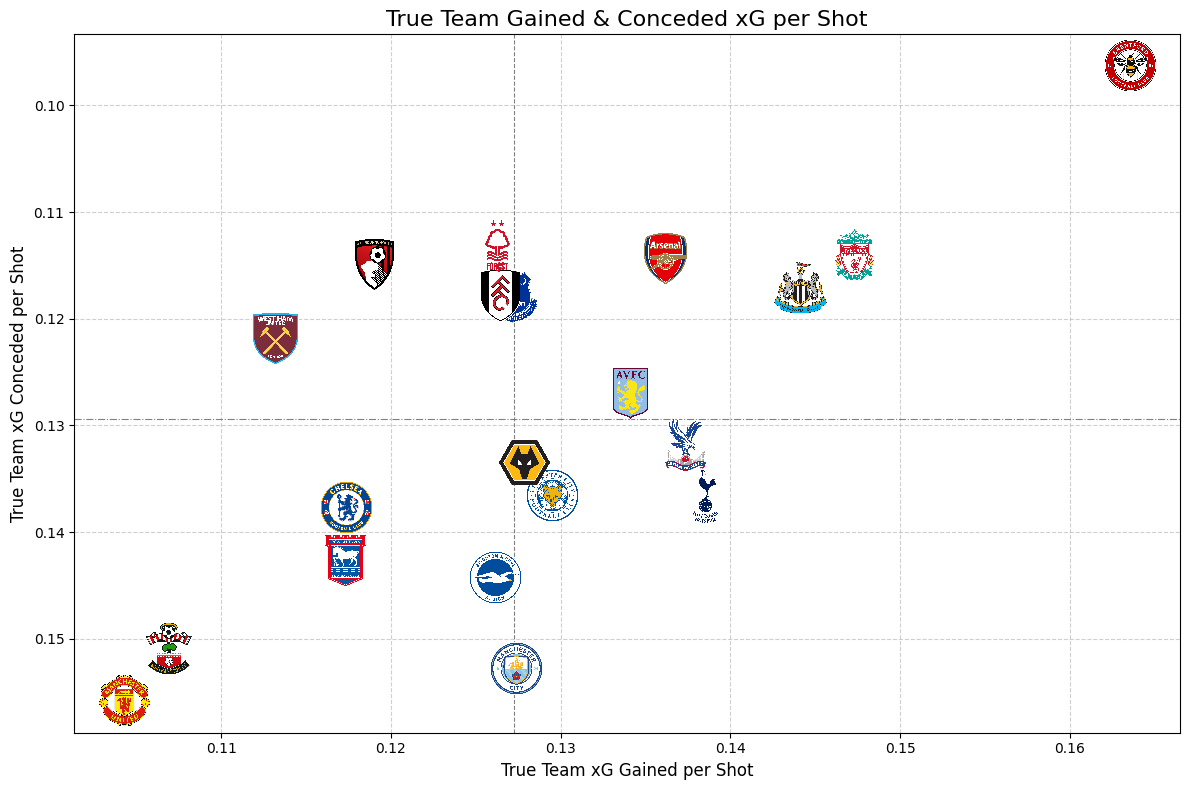

In [93]:
# Prepare the data for plotting (re-creating from original cell logic)
plot_df = team_true_xG_df.copy()

# Create the scatter plot foundation
fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(data=plot_df, x='true_xG_for', y='true_xG_against',
                alpha=0,
                ax=ax) # Set alpha to 0 to make the scatter points invisible, as images will replace them

# Iterate through each team and add their badge as a marker
for index, row in plot_df.iterrows():
    team_name = row['team_name']
    img_path = team_image_mapping.get(team_name)

    if img_path and os.path.exists(img_path):
        try:
            img = mpimg.imread(img_path)
            # Resize the image for better visualization
            imagebox = OffsetImage(img, zoom=0.015) # Adjusted zoom factor
            ab = AnnotationBbox(imagebox, (row['true_xG_for'],
                                           row['true_xG_against']),
                                xycoords='data', frameon=False, pad=0.1)
            ax.add_artist(ab)
        except Exception as e:
            print(f"Could not load image for {team_name} from {img_path}: {e}")
    else:
        print(f"Warning: Image not found for team: {team_name} at path {img_path}")

# Adjust plot title, labels, and grid
plt.title('True Team Gained & Conceded xG per Shot', fontsize=16)
plt.xlabel('True Team xG Gained per Shot', fontsize=12)
plt.ylabel('True Team xG Conceded per Shot', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.axvline(plot_df['true_xG_for'].median(), color='gray', linestyle='--', linewidth=0.8, label='Median True xG Gained per Shot')
plt.axhline(plot_df['true_xG_against'].median(), color='gray', linestyle='-.', linewidth=0.8, label='Median True xG Conceded per Shot')
plt.tight_layout()
plt.gca().invert_yaxis()
plt.show()